In [1]:
!pip install -q transformers accelerate sentence-transformers nltk rouge-score sacrebleu gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 1.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 54.4 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompa

In [2]:
!pip install -q -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 26.2 MB/s eta 0:00:0000:0100:01m


In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("جاري تحميل الموديل...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print(f"الموديل اتحمّل: {MODEL_NAME}")
print(f"الـ device: {model.device}")

جاري تحميل الموديل...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

الموديل اتحمّل: Qwen/Qwen2.5-1.5B-Instruct
الـ device: cuda:0


In [4]:
# قاموس الـ 9 findings بالعربي والإنجليزي
FINDINGS_MAP = {
    "Aortic Enlargement": "تضخم الشريان الأورطي",
    "Cardiomegaly": "تضخم القلب",
    "Consolidation": "تكثف رئوي",
    "Lung Opacity": "عتامة رئوية",
    "Nodule/Mass": "عقدة أو كتلة",
    "Pleural Effusion": "انصباب جنبي",
    "Pleural Thickening": "سماكة غشاء الجنب",
    "Pneumothorax": "استرواح صدري",
    "Pulmonary Fibrosis": "تليف رئوي"
}


def format_findings_for_prompt(findings_dict, threshold=0.5):
    """
    بتحوّل output الموديل لنص منظم للـ prompt
    findings_dict: {"Cardiomegaly": 0.87, "Pleural Effusion": 0.62, ...}
    """
    detected = []
    for finding, confidence in findings_dict.items():
        if confidence >= threshold:
            detected.append(f"- {finding} (confidence: {confidence:.2f})")
    
    if not detected:
        return "No significant abnormalities detected (all findings below threshold)."
    
    return "\n".join(detected)


def generate_report(findings_dict, threshold=0.5, language="en"):
    """
    بتولّد تقرير طبي منظم من الـ findings
    """
    findings_text = format_findings_for_prompt(findings_dict, threshold)
    
    if language == "en":
        system_prompt = """You are an experienced radiologist writing a structured chest X-ray report. 
Write in clear, professional medical language. The report must have THREE sections:

1. FINDINGS: Describe each detected abnormality in 1-2 sentences using proper radiology terminology.
2. IMPRESSION: A concise summary (2-3 sentences) of the most clinically significant findings.
3. RECOMMENDATIONS: Suggested next steps (further imaging, specialist consultation, follow-up timeline).

Be factual and concise. Do NOT invent findings not provided. Do NOT give a definitive diagnosis - 
these are radiological findings that require clinical correlation."""

        user_prompt = f"""Generate a chest X-ray report based on these AI-detected findings:

{findings_text}

Write the report now."""
    
    else:  # Arabic
        system_prompt = """أنت طبيب أشعة خبير بتكتب تقرير منظم لأشعة الصدر.
اكتب بلغة طبية واضحة ومحترفة. التقرير لازم يكون فيه 3 أقسام:

1. النتائج (FINDINGS): اوصف كل علامة مكتشفة في جملة أو اتنين بمصطلحات طبية صحيحة.
2. الانطباع (IMPRESSION): ملخص مختصر (2-3 جمل) لأهم النتائج إكلينيكياً.
3. التوصيات (RECOMMENDATIONS): الخطوات الجاية المقترحة (فحوصات إضافية، استشارة متخصص، موعد المتابعة).

كن دقيق ومختصر. متخترعش نتائج مش موجودة. متديش تشخيص نهائي - 
دي علامات أشعة محتاجة تقييم إكلينيكي."""

        user_prompt = f"""اكتب تقرير أشعة صدر بناءً على النتائج دي اللي اكتشفها الذكاء الاصطناعي:

{findings_text}

اكتب التقرير دلوقتي."""
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )
    
    return response.strip()


print("الدوال جاهزة")

الدوال جاهزة


In [5]:
# حالة وهمية: مريض الموديل اكتشف عنده تضخم قلب وانصباب جنبي
sample_findings = {
    "Cardiomegaly": 0.87,
    "Pleural Effusion": 0.62,
    "Lung Opacity": 0.45,
    "Pneumothorax": 0.12,
    "Aortic Enlargement": 0.08
}

print("=" * 70)
print("ENGLISH REPORT")
print("=" * 70)
report_en = generate_report(sample_findings, threshold=0.5, language="en")
print(report_en)

print("\n" + "=" * 70)
print("ARABIC REPORT")
print("=" * 70)
report_ar = generate_report(sample_findings, threshold=0.5, language="ar")
print(report_ar)

ENGLISH REPORT
**Chest X-Ray Report**

**FINDINGS:**
- **Cardiomegaly**: There is evidence of enlarged cardiac silhouette with increased pulmonary markings bilaterally. This finding suggests a possible enlargement of the heart size, which could be due to various causes such as hypertension, coronary artery disease, or chronic obstructive pulmonary disease (COPD).
- **Pleural Effusion**: There is also a pleural effusion noted, characterized by bilateral reticular opacities suggestive of fluid accumulation between the lung and chest wall. The presence of this effusion indicates mediastinal shift towards the affected side.

**IMPRESSION:**
The patient's chest X-ray demonstrates cardiomegaly and pleural effusion, both of which suggest underlying cardiovascular and respiratory conditions. Further evaluation may include additional imaging studies such as echocardiography for more detailed assessment of the cardiac structure and function, and thoracentesis for confirmation of pleural effusion

In [6]:
def generate_report_v2(findings_dict, threshold=0.5, language="en"):
    """
    نسخة محسّنة من generate_report:
    - max_new_tokens أكبر (مفيش قطع في الآخر)
    - Arabic prompt محسّن مع تحذير قوي ضد الـ hallucination
    - بيمرّر الأسماء العربية للـ findings للموديل
    """
    findings_text = format_findings_for_prompt(findings_dict, threshold)
    
    if language == "en":
        system_prompt = """You are an experienced radiologist writing a structured chest X-ray report. 
Write in clear, professional medical language. The report must have THREE sections:

1. FINDINGS: Describe each detected abnormality in 1-2 sentences using proper radiology terminology.
2. IMPRESSION: A concise summary (2-3 sentences) of the most clinically significant findings.
3. RECOMMENDATIONS: Suggested next steps (further imaging, specialist consultation, follow-up timeline).

CRITICAL RULES:
- Use ONLY the findings provided. Do NOT invent new findings or diseases.
- Do NOT give a definitive diagnosis - these require clinical correlation.
- Be factual and concise."""

        user_prompt = f"""Generate a chest X-ray report based on these AI-detected findings:

{findings_text}

Write the report now."""
    
    else:  # Arabic - محسّن
        # نحوّل الأسماء للعربي للموديل
        detected_ar = []
        for finding, conf in findings_dict.items():
            if conf >= threshold and finding in FINDINGS_MAP:
                detected_ar.append(f"- {FINDINGS_MAP[finding]}")
        
        if not detected_ar:
            detected_ar_text = "لا توجد علامات مرضية واضحة."
        else:
            detected_ar_text = "\n".join(detected_ar)
        
        system_prompt = """أنت طبيب أشعة خبير. اكتب تقرير أشعة صدر منظم بالعربية الفصحى.

التقرير لازم يكون فيه 3 أقسام بالترتيب ده:

**النتائج (FINDINGS):**
اوصف كل علامة من العلامات المعطاة في جملة أو اتنين بمصطلحات طبية صحيحة.

**الانطباع (IMPRESSION):**
ملخص مختصر (2-3 جمل) لأهم النتائج إكلينيكياً.

**التوصيات (RECOMMENDATIONS):**
اقترح خطوات تالية محددة: فحوصات إضافية، استشارة متخصص، موعد المتابعة.

قواعد مهمة جداً:
- استخدم بس العلامات اللي مديتهالك. متخترعش أمراض تانية زي السكري أو الكبد.
- متكتبش نسب أو أرقام نهائياً.
- متديش تشخيص قاطع، قول "تشير إلى احتمال" أو "تتطلب تقييم إضافي".
- اكتب بالعربية الفصحى الكاملة، متستخدمش كلمات إنجليزية."""

        user_prompt = f"""العلامات اللي اكتشفها الذكاء الاصطناعي في أشعة الصدر:

{detected_ar_text}

اكتب التقرير الطبي الكامل دلوقتي."""
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=768,
            do_sample=True,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.15,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )
    
    return response.strip()


# اختبار النسخة المحسّنة على نفس الحالة
print("=" * 70)
print("IMPROVED ARABIC REPORT")
print("=" * 70)
report_ar_v2 = generate_report_v2(sample_findings, threshold=0.5, language="ar")
print(report_ar_v2)

IMPROVED ARABIC REPORT
### التقرير الطبي

#### النتائج (FINDINGS):

1. **تضخم القلب:** تم تحديد وجود تضخم في القلب من خلال الأشعة الصدرية. هذا قد يشير إلى عدة حالات، بما فيها التهاب القلب، الإصابة بأورام داخلية القلب، أو بعض أنواع السكتة الدماغية التي يمكن أن تكون مؤقتة.

2. **إنصابت الجنبين:** تم العثور على إنشاء إنصبتين في الجانب الأيمن للقلب. هذه الحالة قد تعني وجود كيس أو سرطان في الجزء الخلفي من الرئة، وهو ما قد يؤدي إلى ضغوط على القلب وزيادة حجمه.

#### الانطباع (IMPRESSION):
هذه النتائج تشير إلى وجود مشكلات صحية محتملة في الجهاز التنفسي وال cardiovascular. يجب القيام بتقييم إضافي لتحديد نوع المشكلة وتقدير مدى خطورة الحال. 

#### التوصيات (RECOMMENDATIONS):
1. **فحص血液:** يجب إجراء فحص الدم لمعرفة مستوى مستويات الكوليسترول والبروتين والأنسولين، بالإضافة إلى اختبارات أخرى مثل الكشف عن البلاستيزوم والسكري.

2. **تصوير القلب:** قد يتطلب الأمر إجراء تصوير القلب ثلاثي الأبعاد لتحديد موقع الإنصابتين وأسباب وجودهما.

3. **استشارة متخصص:** يجب التواصل مع طبيب.cardiologist أو طبيب الرئتين 

In [7]:
# تحميل Qwen 7B بـ 4-bit quantization عشان يدخل في الـ GPU جنب الصغير
from transformers import BitsAndBytesConfig

LARGE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
)

print("جاري تحميل الموديل الكبير (Qwen 7B)... هياخد 5-10 دقايق")

tokenizer_large = AutoTokenizer.from_pretrained(LARGE_MODEL_NAME)
model_large = AutoModelForCausalLM.from_pretrained(
    LARGE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

print(f"الموديل الكبير اتحمّل: {LARGE_MODEL_NAME}")
print(f"GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

جاري تحميل الموديل الكبير (Qwen 7B)... هياخد 5-10 دقايق


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

الموديل الكبير اتحمّل: Qwen/Qwen2.5-7B-Instruct
GPU memory: 2.76 GB


In [8]:
def generate_arabic_report_large(findings_dict, threshold=0.5):
    """
    بتولّد تقرير عربي باستخدام Qwen 7B
    """
    # نحوّل الأسماء للعربي
    detected_ar = []
    for finding, conf in findings_dict.items():
        if conf >= threshold and finding in FINDINGS_MAP:
            detected_ar.append(f"- {FINDINGS_MAP[finding]}")
    
    if not detected_ar:
        return "لا توجد علامات مرضية واضحة في الأشعة."
    
    detected_ar_text = "\n".join(detected_ar)
    
    system_prompt = """أنت طبيب أشعة خبير متخصص في قراءة أشعة الصدر. مهمتك كتابة تقرير طبي منظم بالعربية الفصحى.

التقرير لازم يكون فيه 3 أقسام بالترتيب ده:

**النتائج (FINDINGS):**
اوصف كل علامة من العلامات المعطاة في جملة أو اتنين بمصطلحات طبية صحيحة.

**الانطباع (IMPRESSION):**
ملخص مختصر (2-3 جمل) لأهم النتائج إكلينيكياً.

**التوصيات (RECOMMENDATIONS):**
اقترح خطوات تالية محددة: فحوصات إضافية، استشارة متخصص، موعد المتابعة.

قواعد صارمة:
- استخدم فقط العلامات المعطاة، لا تخترع أمراض أخرى.
- لا تكتب نسب أو أرقام في التقرير.
- لا تعطي تشخيص قاطع، استخدم عبارات مثل "تشير إلى احتمال" أو "تتطلب تقييم إضافي".
- اكتب بالعربية الفصحى الكاملة فقط، بدون أي كلمات إنجليزية في النص.
- التزم بالمصطلحات الطبية الصحيحة."""

    user_prompt = f"""العلامات المكتشفة في أشعة الصدر:

{detected_ar_text}

اكتب التقرير الطبي الكامل بالعربية الفصحى."""
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text = tokenizer_large.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer_large(text, return_tensors="pt").to(model_large.device)
    
    with torch.no_grad():
        outputs = model_large.generate(
            **inputs,
            max_new_tokens=768,
            do_sample=True,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer_large.eos_token_id
        )
    
    response = tokenizer_large.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )
    
    return response.strip()


# اختبار على نفس الحالة
print("=" * 70)
print("ARABIC REPORT - Qwen 7B (LARGE MODEL)")
print("=" * 70)
import time
start = time.time()
report_ar_large = generate_arabic_report_large(sample_findings, threshold=0.5)
elapsed = time.time() - start
print(report_ar_large)
print(f"\n⏱️ Generation time: {elapsed:.1f} seconds")

ARABIC REPORT - Qwen 7B (LARGE MODEL)
**النتائج (FINDINGS):**

1. تضخم القلب: يظهر التضخم البطيني الأيمن واليسرى للقلب مما يتطلب تقييمًا إضافيًا للتحديد الدقيق.
2. انصباج جنبي: يوجد انصباج حاد في الرئتين اليسرى والحقية مع وجود منطقة غير واضحة في الجانب الأيسر من الصدر.

**الانطباع (IMPRESSION):**

تشير النتائج إلى احتمال وجود حالة تضخم قلبي وانصباج رئوي حاد، مما يتطلب تقييمًا إضافيًا للتأكيد على التشخيص وإجراء فحوصات مخبرية ودقيقة للرئة.

**التوصيات (RECOMMENDATIONS):**

تتطلب هذه النتائج إجراء فحوصات الدم لقياس مستوى البروتين C Reactive وD-dimer بالإضافة إلى فحص دم كيميائي شامل. كما يتوجب استشارة متخصص في الأمراض الصدرية لمزيد من التقييم والإشراف الطبي. بالإضافة إلى ذلك، يجب تحديد موعد للمراجعة بعد أسبوعين للاطمئنان على الاستجابة للعلاج.

⏱️ Generation time: 24.7 seconds


In [9]:
import re

# قاموس التصحيحات الطبية: الغلط → الصح
MEDICAL_CORRECTIONS = {
    # أخطاء "انصباج" و "انصباب جنيني"
    "انصباج جنيني": "انصباب جنبي",
    "انصباج جنبي": "انصباب جنبي",
    "انصباب جنيني": "انصباب جنبي",
    "إنصباج جنيني": "انصباب جنبي",
    "إنصباج جنبي": "انصباب جنبي",
    "انصباج": "انصباب",
    "إنصباج": "انصباب",
    
    # أخطاء وصف الانصباب
    "سوائل داخل الرئتين": "سوائل حول الرئة في الحيز الجنبي",
    "سوائل داخل الرئة": "سوائل حول الرئة في الحيز الجنبي",
    "سائل داخل الرئة": "سائل حول الرئة في الحيز الجنبي",
    "السوائل داخل الرئتين": "السوائل حول الرئة في الحيز الجنبي",
    
    # أخطاء استرواح صدري
    "استرواح صدر": "استرواح صدري",
    "إسترواح": "استرواح",
    "هواء في الرئة": "هواء في الحيز الجنبي",
    "هواء داخل الرئة": "هواء في الحيز الجنبي",
    
    # أخطاء تليف
    "تليف في الرئة": "تليف رئوي",
    "تليفات": "تليف",
    
    # أخطاء عقدة/كتلة
    "عقيدة": "عقدة",
    "ورم في الرئة": "كتلة في الرئة",
    
    # أخطاء الشريان الأورطي
    "الأبهر": "الشريان الأورطي",
    "الأورطى": "الأورطي",
    "أورطى": "أورطي",
    
    # أخطاء غشاء الجنب
    "غشاء الجنبي": "الغشاء الجنبي",
    "غشاء جنب": "غشاء الجنب",
    "البلورا": "غشاء الجنب",
    
    # أخطاء عامة في الطب
    "تكثف الرئة": "تكثف رئوي",
    "إلتهاب": "التهاب",
    "إعتلال": "اعتلال",
    "إكلينيكى": "إكلينيكي",
    "إكلينيكيا": "إكلينيكياً",
    
    # تنظيف
    " ،": "،",
    "  ": " ",
}


def post_process_arabic_report(report_text):
    """
    بتصلح الأخطاء الطبية المعروفة في التقرير العربي
    """
    corrected = report_text
    
    # تطبيق التصحيحات
    for wrong, correct in MEDICAL_CORRECTIONS.items():
        corrected = corrected.replace(wrong, correct)
    
    # إزالة أي كلمات إنجليزية أو حروف غير عربية في النص (ما عدا الترقيم والأرقام)
    # نسيب بس: عربي، أرقام، علامات ترقيم، نيو لاين، علامات تنسيق ماركداون
    
    # إزالة الحروف الصينية واليابانية تحديداً
    corrected = re.sub(r'[\u4e00-\u9fff\u3040-\u309f\u30a0-\u30ff]+', '', corrected)
    
    # تنظيف المسافات الزيادة
    corrected = re.sub(r' +', ' ', corrected)
    corrected = re.sub(r'\n{3,}', '\n\n', corrected)
    
    return corrected.strip()


def generate_arabic_report_hybrid(findings_dict, threshold=0.5):
    """
    Hybrid: Qwen 7B + Post-processing
    """
    # 1. توليد بالموديل
    raw_report = generate_arabic_report_large(findings_dict, threshold)
    
    # 2. تصحيح الأخطاء
    corrected_report = post_process_arabic_report(raw_report)
    
    return raw_report, corrected_report


# اختبار: نشوف قبل وبعد
print("=" * 70)
print("BEFORE (Raw 7B Output)")
print("=" * 70)
import time
start = time.time()
raw, corrected = generate_arabic_report_hybrid(sample_findings, threshold=0.5)
elapsed = time.time() - start
print(raw)

print("\n" + "=" * 70)
print("AFTER (Post-Processed)")
print("=" * 70)
print(corrected)
print(f"\n⏱️ Total time: {elapsed:.1f} seconds")

# نعد الأخطاء اللي اتصلحت
changes = sum(1 for w, c in MEDICAL_CORRECTIONS.items() if w in raw)
print(f"🔧 Corrections applied: {changes}")

BEFORE (Raw 7B Output)
**النتائج (FINDINGS):**

1. هناك تضخم في حجم القلب مما يشير إلى احتمال وجود مشكلة في وظائف القلب.
2. يوجد انصباج في الرئتين الجنبية مما يشير إلى احتمال وجود تورم في الأوعية الدموية الجنبية.

**الانطباع (IMPRESSION):**

تشير النتائج إلى احتمال وجود مشكلة في وظائف القلب وتورم في الأوعية الدموية الجنبية، مما يتطلب تقييمًا إضافيًا للتأكيد على التشخيص.

**التوصيات (RECOMMENDATIONS):**

يتطلب هذا الحالة توجه المريض لمتابعة مع طبيب القلب لإجراء فحوصات إضافية مثل الاختبارات الكيميائية القلبية والتصوير الشعاعي للقلب. كما يتطلب الأمر استشارة طبيب البولونكولوجيا للفحص والعلاج المحتمل للتورم الجنبى. بالإضافة إلى ذلك، يجب تحديد موعد للمراجعة بعد ثلاثة أشهر لتقييم التحسن.

AFTER (Post-Processed)
**النتائج (FINDINGS):**

1. هناك تضخم في حجم القلب مما يشير إلى احتمال وجود مشكلة في وظائف القلب.
2. يوجد انصباب في الرئتين الجنبية مما يشير إلى احتمال وجود تورم في الأوعية الدموية الجنبية.

**الانطباع (IMPRESSION):**

تشير النتائج إلى احتمال وجود مشكلة في وظائف القلب وتورم في الأوعية 

In [5]:
# قاموس طبي عربي منظم لكل finding - مكتوب يدوياً بمصطلحات طبية صحيحة
ARABIC_MEDICAL_DB = {
    "Aortic Enlargement": {
        "name": "تضخم الشريان الأورطي",
        "finding": "يُلاحظ اتساع في قطر الشريان الأورطي عن المعدل الطبيعي.",
        "impression": "النتائج تشير إلى احتمال وجود تمدد في الشريان الأورطي، مما يستدعي تقييماً إضافياً.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر مع صبغة لتقييم حجم الشريان بدقة، ومتابعة مع طبيب أمراض القلب والأوعية الدموية."
    },
    "Cardiomegaly": {
        "name": "تضخم القلب",
        "finding": "ظل القلب يظهر متضخماً مع زيادة في النسبة القلبية الصدرية.",
        "impression": "تشير النتائج إلى تضخم في حجم القلب، وهي علامة قد ترتبط بحالات مثل ارتفاع ضغط الدم، أمراض الصمامات، أو قصور القلب.",
        "recommendation": "يُنصح بإجراء تخطيط صدى القلب (Echocardiogram) لتقييم وظيفة القلب وحجم حجراته، واستشارة طبيب القلب."
    },
    "Consolidation": {
        "name": "تكثف رئوي",
        "finding": "تظهر مناطق من التكثف في النسيج الرئوي مع فقدان للشفافية الطبيعية.",
        "impression": "النتائج تتوافق مع وجود تكثف رئوي، وهي علامة شائعة في الالتهاب الرئوي أو حالات أخرى تستدعي التقييم.",
        "recommendation": "يُنصح بإجراء تحاليل دم شاملة، وزراعة بلغم إذا أمكن، وبدء العلاج المناسب تحت إشراف طبيب الباطنة أو الصدر."
    },
    "Lung Opacity": {
        "name": "عتامة رئوية",
        "finding": "تُلاحظ مناطق من العتامة في النسيج الرئوي تختلف عن المظهر الطبيعي.",
        "impression": "العتامة الرئوية علامة غير محددة قد تشير إلى التهاب، تكثف، أو وجود سوائل، وتحتاج إلى تقييم إكلينيكي.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر لتحديد طبيعة العتامة، ومتابعة مع طبيب الأمراض الصدرية."
    },
    "Nodule/Mass": {
        "name": "عقدة أو كتلة",
        "finding": "تظهر عقدة أو كتلة محددة في النسيج الرئوي.",
        "impression": "وجود عقدة رئوية يستدعي تقييماً دقيقاً لاستبعاد الحالات الخطيرة، علماً بأن أغلب العقد تكون حميدة.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر بدقة عالية، ومتابعة منتظمة، واستشارة طبيب الأورام أو الصدر حسب التقييم."
    },
    "Pleural Effusion": {
        "name": "انصباب جنبي",
        "finding": "يُلاحظ تجمع للسوائل في الحيز الجنبي حول الرئة.",
        "impression": "وجود انصباب جنبي علامة قد ترتبط بأسباب متعددة منها قصور القلب، الالتهابات، أو حالات أخرى تتطلب التشخيص.",
        "recommendation": "يُنصح بإجراء فحوصات إضافية لتحديد سبب الانصباب، وقد يحتاج المريض إلى سحب عينة من السائل للتحليل (Thoracentesis)."
    },
    "Pleural Thickening": {
        "name": "سماكة غشاء الجنب",
        "finding": "يُلاحظ زيادة في سماكة الغشاء الجنبي المحيط بالرئة.",
        "impression": "سماكة الغشاء الجنبي قد تكون نتيجة التهاب سابق، تعرض لمواد ضارة، أو حالات مزمنة.",
        "recommendation": "يُنصح بأخذ التاريخ المرضي بدقة (خاصة التعرض المهني)، وإجراء أشعة مقطعية للتقييم التفصيلي."
    },
    "Pneumothorax": {
        "name": "استرواح صدري",
        "finding": "يُلاحظ وجود هواء في الحيز الجنبي مع انخماص جزئي في الرئة.",
        "impression": "الاسترواح الصدري حالة تستدعي تقييماً عاجلاً، وقد تحتاج تدخلاً سريعاً حسب حجمها وأعراض المريض.",
        "recommendation": "يُنصح بالتقييم العاجل في الطوارئ، وقد يحتاج المريض إلى تركيب أنبوب صدري لتصريف الهواء."
    },
    "Pulmonary Fibrosis": {
        "name": "تليف رئوي",
        "finding": "تظهر علامات تليف في النسيج الرئوي مع نمط شبكي مميز.",
        "impression": "التليف الرئوي حالة مزمنة تؤثر على وظيفة الرئة، وتحتاج إلى تقييم وتشخيص دقيق للسبب.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية عالية الدقة (HRCT)، اختبارات وظائف الرئة، ومتابعة مع طبيب الأمراض الصدرية."
    }
}


def build_arabic_report(findings_dict, threshold=0.5):
    """
    بتبني تقرير عربي منظم من template
    مفيش LLM = مفيش hallucination
    """
    # فلترة وترتيب الـ findings
    detected = [(f, c) for f, c in findings_dict.items() 
                if c >= threshold and f in ARABIC_MEDICAL_DB]
    
    if not detected:
        return """### تقرير أشعة الصدر

**النتائج (FINDINGS):**
لا توجد علامات مرضية واضحة في الأشعة. ظل القلب طبيعي، والحقول الرئوية تبدو خالية من أي تكثف أو عتامة واضحة.

**الانطباع (IMPRESSION):**
أشعة صدر طبيعية في حدود ما تظهره الصورة. لا توجد علامات تستدعي قلقاً فورياً.

**التوصيات (RECOMMENDATIONS):**
المتابعة الروتينية مع الطبيب المعالج، والرجوع للتقييم في حالة ظهور أي أعراض جديدة.

---
*ملاحظة: هذا التقرير تم توليده آلياً بناءً على تحليل الذكاء الاصطناعي للأشعة، ويحتاج إلى مراجعة من طبيب أشعة مختص.*"""
    
    # ترتيب حسب درجة الثقة (الأعلى أولاً)
    detected.sort(key=lambda x: x[1], reverse=True)
    
    # بناء الأقسام
    findings_lines = []
    impressions = []
    recommendations = []
    
    for i, (finding, conf) in enumerate(detected, 1):
        info = ARABIC_MEDICAL_DB[finding]
        findings_lines.append(f"{i}. **{info['name']}**: {info['finding']}")
        impressions.append(info['impression'])
        recommendations.append(f"{i}. {info['recommendation']}")
    
    report = f"""### تقرير أشعة الصدر

**النتائج (FINDINGS):**
{chr(10).join(findings_lines)}

**الانطباع (IMPRESSION):**
{' '.join(impressions)}

**التوصيات (RECOMMENDATIONS):**
{chr(10).join(recommendations)}

---
*ملاحظة: هذا التقرير تم توليده آلياً بناءً على تحليل الذكاء الاصطناعي للأشعة، ويحتاج إلى مراجعة من طبيب أشعة مختص.*"""
    
    return report


# اختبار سريع
import time
print("=" * 70)
print("ARABIC TEMPLATE REPORT")
print("=" * 70)
start = time.time()
report_ar_template = build_arabic_report(sample_findings, threshold=0.5)
elapsed = time.time() - start
print(report_ar_template)
print(f"\n⏱️ Generation time: {elapsed*1000:.1f} milliseconds")

ARABIC TEMPLATE REPORT
### تقرير أشعة الصدر

**النتائج (FINDINGS):**
1. **تضخم القلب**: ظل القلب يظهر متضخماً مع زيادة في النسبة القلبية الصدرية.

**الانطباع (IMPRESSION):**
تشير النتائج إلى تضخم في حجم القلب، وهي علامة قد ترتبط بحالات مثل ارتفاع ضغط الدم، أمراض الصمامات، أو قصور القلب.

**التوصيات (RECOMMENDATIONS):**
1. يُنصح بإجراء تخطيط صدى القلب (Echocardiogram) لتقييم وظيفة القلب وحجم حجراته، واستشارة طبيب القلب.

---
*ملاحظة: هذا التقرير تم توليده آلياً بناءً على تحليل الذكاء الاصطناعي للأشعة، ويحتاج إلى مراجعة من طبيب أشعة مختص.*

⏱️ Generation time: 0.1 milliseconds


In [4]:
sample_findings = {
    "Cardiomegaly": 0.87,
    "Pleural effusion": 0.62,
    "Lung Opacity": 0.45,
    "Pneumothorax": 0.12,
    "Aortic enlargement": 0.08
}

print("✅ sample_findings جاهزة")

✅ sample_findings جاهزة


In [11]:
import time

def comprehensive_comparison(findings_dict, threshold=0.5):
    """
    بتقارن بين الـ 3 approaches للتقرير العربي:
    1. Qwen 1.5B (Small LLM)
    2. Qwen 7B (Large LLM)
    3. Template (Rule-based)
    """
    results = {}
    
    # Method 1: Small Model (1.5B)
    print("⏳ Running Qwen 1.5B...")
    start = time.time()
    report_small = generate_report_v2(findings_dict, threshold, language="ar")
    results['small_llm'] = {
        'report': report_small,
        'time': time.time() - start,
        'method': 'Qwen 2.5 1.5B (Small LLM)'
    }
    
    # Method 2: Large Model (7B)
    print("⏳ Running Qwen 7B...")
    start = time.time()
    report_large = generate_arabic_report_large(findings_dict, threshold)
    results['large_llm'] = {
        'report': report_large,
        'time': time.time() - start,
        'method': 'Qwen 2.5 7B (Large LLM)'
    }
    
    # Method 3: Template
    print("⏳ Running Template...")
    start = time.time()
    report_template = build_arabic_report(findings_dict, threshold)
    results['template'] = {
        'report': report_template,
        'time': time.time() - start,
        'method': 'Rule-based Template'
    }
    
    return results


# نشغّله على نفس الحالة
print("=" * 70)
print("COMPREHENSIVE COMPARISON")
print("=" * 70)
print(f"Findings: {sample_findings}")
print("=" * 70)

comparison_results = comprehensive_comparison(sample_findings, threshold=0.5)

# عرض النتائج
for key, data in comparison_results.items():
    print(f"\n{'=' * 70}")
    print(f"METHOD: {data['method']}")
    print(f"TIME: {data['time']:.3f} seconds")
    print(f"{'=' * 70}")
    print(data['report'])
    print()

# جدول ملخص
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(f"{'Method':<35} {'Time':<15} {'Speed Rank':<10}")
print("-" * 60)

sorted_results = sorted(comparison_results.items(), key=lambda x: x[1]['time'])
for rank, (key, data) in enumerate(sorted_results, 1):
    print(f"{data['method']:<35} {data['time']:.3f}s{'':<8} #{rank}")

COMPREHENSIVE COMPARISON
Findings: {'Cardiomegaly': 0.87, 'Pleural Effusion': 0.62, 'Lung Opacity': 0.45, 'Pneumothorax': 0.12, 'Aortic Enlargement': 0.08}
⏳ Running Qwen 1.5B...
⏳ Running Qwen 7B...
⏳ Running Template...

METHOD: Qwen 2.5 1.5B (Small LLM)
TIME: 27.824 seconds
**التقرير الطبي**

**النتائج (FINDINGS):**

1. **تضخم القلب:** تم العثور على تضخم قليل للقلب، حيث يظهر زيادة في حجم القلب وحجم الأوعية الدموية المرتبطة به. هذا قد يشير إلى وجود مشكلة صحية مثل الإصابة بأورام أو التهابات القلب.

2. **إنصابت الجنب:** توجد إنشادًا واضحة وجذابة في الجزء الأمامي والخلفي من الرقبة، مما يدل على أن هناك ضغطاً كبيرًا على هذه المناطق. هذا قد يشير إلى وجود مشكلة في الجهاز الهضمي أو بعض الحالات الصحية الأخرى التي تتسبب في الضغط على هذه المناطق.

**الانطباع (IMPRESSION):**

من خلال فحص الأشعة، يمكننا أن نلاحظ وجود تضخم قليل للقلب وأيضًا إنشاد واضح وجذاب في الجزء الأمامي والخلفي من الرقبة. هذه العلامات تشير إلى احتمال وجود مشكلة صحية، خاصة إذا كانت هذه المشاكل تؤثر على صحتنا بشكل مباشر. 

بشكل 

In [12]:
# نحفظ المقارنة في ملف نصي للتوثيق في الـ thesis/presentation
import os

os.makedirs("/kaggle/working/comparison_results", exist_ok=True)

with open("/kaggle/working/comparison_results/arabic_methods_comparison.txt", "w", encoding="utf-8") as f:
    f.write("=" * 70 + "\n")
    f.write("ARABIC REPORT GENERATION - METHODS COMPARISON\n")
    f.write("=" * 70 + "\n")
    f.write(f"\nInput Findings: {sample_findings}\n")
    f.write(f"Threshold: 0.5\n\n")
    
    for key, data in comparison_results.items():
        f.write("=" * 70 + "\n")
        f.write(f"METHOD: {data['method']}\n")
        f.write(f"TIME: {data['time']:.3f} seconds\n")
        f.write("=" * 70 + "\n")
        f.write(data['report'] + "\n\n")
    
    f.write("=" * 70 + "\n")
    f.write("CONCLUSION\n")
    f.write("=" * 70 + "\n")
    f.write("""
Based on this comparison, the Rule-based Template approach was selected 
for Arabic report generation due to:

1. Zero medical hallucination (vs 2-4 errors per report in LLM approaches)
2. Instantaneous generation (0.0001s vs 27+ seconds)
3. Predictable, medically-accurate terminology
4. Better suited for safety-critical medical applications

The LLM approach (Qwen 1.5B) is retained for English reports, where the 
model demonstrates significantly better medical fluency.

This creates a hybrid system: LLM for English, Template for Arabic.
""")

print("✅ تم حفظ المقارنة في:")
print("/kaggle/working/comparison_results/arabic_methods_comparison.txt")

✅ تم حفظ المقارنة في:
/kaggle/working/comparison_results/arabic_methods_comparison.txt


In [8]:
# الـ classes زي ما هما في موديل زمايلك بالظبط (lowercase consistency)
CLASSIFIER_CLASSES = [
    "Aortic enlargement",
    "Cardiomegaly", 
    "Consolidation",
    "Lung Opacity",
    "Nodule/Mass",
    "Pleural effusion",
    "Pleural thickening",
    "Pneumothorax",
    "Pulmonary fibrosis",
]

# نحدث الـ FINDINGS_MAP عشان يماثل أسماء موديلهم بالظبط
FINDINGS_MAP = {
    "Aortic enlargement": "تضخم الشريان الأورطي",
    "Cardiomegaly": "تضخم القلب",
    "Consolidation": "تكثف رئوي",
    "Lung Opacity": "عتامة رئوية",
    "Nodule/Mass": "عقدة أو كتلة",
    "Pleural effusion": "انصباب جنبي",
    "Pleural thickening": "سماكة غشاء الجنب",
    "Pneumothorax": "استرواح صدري",
    "Pulmonary fibrosis": "تليف رئوي"
}

# نحدّث الـ Arabic Medical DB بنفس الأسماء
ARABIC_MEDICAL_DB = {
    "Aortic enlargement": {
        "name": "تضخم الشريان الأورطي",
        "finding": "يُلاحظ اتساع في قطر الشريان الأورطي عن المعدل الطبيعي.",
        "impression": "النتائج تشير إلى احتمال وجود تمدد في الشريان الأورطي، مما يستدعي تقييماً إضافياً.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر مع صبغة لتقييم حجم الشريان بدقة، ومتابعة مع طبيب أمراض القلب والأوعية الدموية."
    },
    "Cardiomegaly": {
        "name": "تضخم القلب",
        "finding": "ظل القلب يظهر متضخماً مع زيادة في النسبة القلبية الصدرية.",
        "impression": "تشير النتائج إلى تضخم في حجم القلب، وهي علامة قد ترتبط بحالات مثل ارتفاع ضغط الدم، أمراض الصمامات، أو قصور القلب.",
        "recommendation": "يُنصح بإجراء تخطيط صدى القلب (Echocardiogram) لتقييم وظيفة القلب وحجم حجراته، واستشارة طبيب القلب."
    },
    "Consolidation": {
        "name": "تكثف رئوي",
        "finding": "تظهر مناطق من التكثف في النسيج الرئوي مع فقدان للشفافية الطبيعية.",
        "impression": "النتائج تتوافق مع وجود تكثف رئوي، وهي علامة شائعة في الالتهاب الرئوي أو حالات أخرى تستدعي التقييم.",
        "recommendation": "يُنصح بإجراء تحاليل دم شاملة، وزراعة بلغم إذا أمكن، وبدء العلاج المناسب تحت إشراف طبيب الباطنة أو الصدر."
    },
    "Lung Opacity": {
        "name": "عتامة رئوية",
        "finding": "تُلاحظ مناطق من العتامة في النسيج الرئوي تختلف عن المظهر الطبيعي.",
        "impression": "العتامة الرئوية علامة غير محددة قد تشير إلى التهاب، تكثف، أو وجود سوائل، وتحتاج إلى تقييم إكلينيكي.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر لتحديد طبيعة العتامة، ومتابعة مع طبيب الأمراض الصدرية."
    },
    "Nodule/Mass": {
        "name": "عقدة أو كتلة",
        "finding": "تظهر عقدة أو كتلة محددة في النسيج الرئوي.",
        "impression": "وجود عقدة رئوية يستدعي تقييماً دقيقاً لاستبعاد الحالات الخطيرة، علماً بأن أغلب العقد تكون حميدة.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية للصدر بدقة عالية، ومتابعة منتظمة، واستشارة طبيب الأورام أو الصدر حسب التقييم."
    },
    "Pleural effusion": {
        "name": "انصباب جنبي",
        "finding": "يُلاحظ تجمع للسوائل في الحيز الجنبي حول الرئة.",
        "impression": "وجود انصباب جنبي علامة قد ترتبط بأسباب متعددة منها قصور القلب، الالتهابات، أو حالات أخرى تتطلب التشخيص.",
        "recommendation": "يُنصح بإجراء فحوصات إضافية لتحديد سبب الانصباب، وقد يحتاج المريض إلى سحب عينة من السائل للتحليل (Thoracentesis)."
    },
    "Pleural thickening": {
        "name": "سماكة غشاء الجنب",
        "finding": "يُلاحظ زيادة في سماكة الغشاء الجنبي المحيط بالرئة.",
        "impression": "سماكة الغشاء الجنبي قد تكون نتيجة التهاب سابق، تعرض لمواد ضارة، أو حالات مزمنة.",
        "recommendation": "يُنصح بأخذ التاريخ المرضي بدقة (خاصة التعرض المهني)، وإجراء أشعة مقطعية للتقييم التفصيلي."
    },
    "Pneumothorax": {
        "name": "استرواح صدري",
        "finding": "يُلاحظ وجود هواء في الحيز الجنبي مع انخماص جزئي في الرئة.",
        "impression": "الاسترواح الصدري حالة تستدعي تقييماً عاجلاً، وقد تحتاج تدخلاً سريعاً حسب حجمها وأعراض المريض.",
        "recommendation": "يُنصح بالتقييم العاجل في الطوارئ، وقد يحتاج المريض إلى تركيب أنبوب صدري لتصريف الهواء."
    },
    "Pulmonary fibrosis": {
        "name": "تليف رئوي",
        "finding": "تظهر علامات تليف في النسيج الرئوي مع نمط شبكي مميز.",
        "impression": "التليف الرئوي حالة مزمنة تؤثر على وظيفة الرئة، وتحتاج إلى تقييم وتشخيص دقيق للسبب.",
        "recommendation": "يُنصح بإجراء أشعة مقطعية عالية الدقة (HRCT)، اختبارات وظائف الرئة، ومتابعة مع طبيب الأمراض الصدرية."
    }
}

print(f"✅ تم تحديث الـ Maps:")
print(f"   عدد الـ classes: {len(CLASSIFIER_CLASSES)}")
print(f"   عدد entries في FINDINGS_MAP: {len(FINDINGS_MAP)}")
print(f"   عدد entries في ARABIC_MEDICAL_DB: {len(ARABIC_MEDICAL_DB)}")

# نتأكد إن الـ keys في كل القواميس متطابقة
assert set(CLASSIFIER_CLASSES) == set(FINDINGS_MAP.keys()) == set(ARABIC_MEDICAL_DB.keys()), \
    "الـ keys مش متطابقة بين القواميس!"
print("✅ كل القواميس متطابقة")

✅ تم تحديث الـ Maps:
   عدد الـ classes: 9
   عدد entries في FINDINGS_MAP: 9
   عدد entries في ARABIC_MEDICAL_DB: 9
✅ كل القواميس متطابقة


In [9]:
class MockClassifier:
    """
    موديل وهمي بيطلّع 9 probabilities عشوائية
    استخدمه لاختبار الـ pipeline لحد ما يجي الموديل الحقيقي
    """
    def __init__(self):
        self.classes = CLASSIFIER_CLASSES
        print(f"⚠️ Mock Classifier محمّل (للاختبار فقط)")
        print(f"   هيتم استبداله بـ RAD-DINO الحقيقي لما يجي")
    
    def predict(self, image=None):
        """
        بيرجّع dict فيه الـ 9 findings مع probabilities عشوائية
        في الواقع الموديل الحقيقي هياخد الصورة ويطلّع نفس الـ format
        """
        import random
        # نخلي 2-4 findings ايجابية (>0.5) عشان نختبر التقرير
        probs = {}
        n_positive = random.randint(2, 4)
        positive_indices = random.sample(range(len(self.classes)), n_positive)
        
        for i, cls in enumerate(self.classes):
            if i in positive_indices:
                # ايجابي: 0.55 - 0.95
                probs[cls] = round(random.uniform(0.55, 0.95), 3)
            else:
                # سلبي: 0.01 - 0.45
                probs[cls] = round(random.uniform(0.01, 0.45), 3)
        
        return probs


# اختبار: نولّد حالة وهمية ونشوف التقرير
mock_classifier = MockClassifier()

print("\n" + "=" * 70)
print("MOCK PREDICTION (لاختبار الـ pipeline)")
print("=" * 70)
mock_findings = mock_classifier.predict()
print("\nالـ findings المتولّدة عشوائياً:")
for cls, prob in sorted(mock_findings.items(), key=lambda x: x[1], reverse=True):
    indicator = "🔴" if prob >= 0.5 else "⚪"
    print(f"  {indicator} {cls:25s}: {prob:.3f}")

print("\n" + "=" * 70)
print("الـ Arabic Template Report")
print("=" * 70)
print(build_arabic_report(mock_findings, threshold=0.5))

⚠️ Mock Classifier محمّل (للاختبار فقط)
   هيتم استبداله بـ RAD-DINO الحقيقي لما يجي

MOCK PREDICTION (لاختبار الـ pipeline)

الـ findings المتولّدة عشوائياً:
  🔴 Pleural thickening       : 0.797
  🔴 Nodule/Mass              : 0.745
  🔴 Pleural effusion         : 0.684
  🔴 Pneumothorax             : 0.579
  ⚪ Pulmonary fibrosis       : 0.420
  ⚪ Cardiomegaly             : 0.313
  ⚪ Consolidation            : 0.302
  ⚪ Lung Opacity             : 0.191
  ⚪ Aortic enlargement       : 0.024

الـ Arabic Template Report
### تقرير أشعة الصدر

**النتائج (FINDINGS):**
1. **سماكة غشاء الجنب**: يُلاحظ زيادة في سماكة الغشاء الجنبي المحيط بالرئة.
2. **عقدة أو كتلة**: تظهر عقدة أو كتلة محددة في النسيج الرئوي.
3. **انصباب جنبي**: يُلاحظ تجمع للسوائل في الحيز الجنبي حول الرئة.
4. **استرواح صدري**: يُلاحظ وجود هواء في الحيز الجنبي مع انخماص جزئي في الرئة.

**الانطباع (IMPRESSION):**
سماكة الغشاء الجنبي قد تكون نتيجة التهاب سابق، تعرض لمواد ضارة، أو حالات مزمنة. وجود عقدة رئوية يستدعي تقييماً دقيقاً لاس

In [10]:
# نفحص هل الـ DB متحدثة فعلاً
print("Keys في ARABIC_MEDICAL_DB:")
for k in ARABIC_MEDICAL_DB.keys():
    print(f"  '{k}'")

print(f"\nالعدد: {len(ARABIC_MEDICAL_DB)}")
print(f"\nهل 'Pleural thickening' (t صغيرة) موجودة؟ {'Pleural thickening' in ARABIC_MEDICAL_DB}")
print(f"هل 'Pleural Thickening' (T كبيرة) موجودة؟ {'Pleural Thickening' in ARABIC_MEDICAL_DB}")

Keys في ARABIC_MEDICAL_DB:
  'Aortic enlargement'
  'Cardiomegaly'
  'Consolidation'
  'Lung Opacity'
  'Nodule/Mass'
  'Pleural effusion'
  'Pleural thickening'
  'Pneumothorax'
  'Pulmonary fibrosis'

العدد: 9

هل 'Pleural thickening' (t صغيرة) موجودة؟ True
هل 'Pleural Thickening' (T كبيرة) موجودة؟ False


In [11]:
import os

# نشوف الـ path الكامل ونتأكد من الملفات
INPUT_DIR = "/kaggle/input"

print("=" * 70)
print("استكشاف المسار:")
print("=" * 70)

for root, dirs, files in os.walk(INPUT_DIR):
    # نطبع كل المسار اللي فيه ملفات .pth أو .json
    relevant_files = [f for f in files if f.endswith(('.pth', '.json'))]
    if relevant_files:
        print(f"\n📁 {root}")
        for f in sorted(relevant_files):
            full_path = os.path.join(root, f)
            size_mb = os.path.getsize(full_path) / (1024 * 1024)
            print(f"   {f}  ({size_mb:.1f} MB)")

استكشاف المسار:

📁 /kaggle/input/models/refaatelia/ep10/pytorch/default/1
   __huggingface_repos__.json  (0.0 MB)
   best_model.pth  (1321.6 MB)
   best_model_ema.pth  (330.4 MB)
   checkpoint_round1_epoch_08.pth  (660.8 MB)
   checkpoint_round1_epoch_09.pth  (660.8 MB)
   checkpoint_round1_epoch_10.pth  (660.8 MB)
   optimal_thresholds.json  (0.0 MB)


In [12]:
from transformers import AutoModel
import torch.nn as nn

class RadDinoModel(nn.Module):
    """
    موديل RAD-DINO للتصنيف
    نفس الـ architecture بتاع زمايلك بالظبط
    """
    def __init__(self, num_classes=9, dropout=0.3):
        super().__init__()
        # نحمّل الـ backbone من Hugging Face
        print(f"  تحميل microsoft/rad-dino backbone...")
        self.backbone = AutoModel.from_pretrained("microsoft/rad-dino")
        feat_dim = self.backbone.config.hidden_size  # 768
        
        # الـ classification head
        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, num_classes),
        )
        print(f"  ✅ RAD-DINO جاهز: feat_dim={feat_dim}, num_classes={num_classes}")
    
    def forward(self, x):
        out = self.backbone(pixel_values=x)
        cls = out.last_hidden_state[:, 0]  # CLS token
        return self.head(cls)


print("✅ كلاس RadDinoModel متعرّف")

✅ كلاس RadDinoModel متعرّف


In [14]:
import torch
import json

# المسارات
WEIGHTS_PATH = "/kaggle/input/models/refaatelia/ep10/pytorch/default/1/best_model_ema.pth"
THRESHOLDS_PATH = "/kaggle/input/models/refaatelia/ep10/pytorch/default/1/optimal_thresholds.json"

print("=" * 70)
print("استكشاف الـ checkpoint")
print("=" * 70)

print(f"\nجاري تحميل الـ weights من:")
print(f"  {WEIGHTS_PATH}")

checkpoint = torch.load(WEIGHTS_PATH, map_location="cuda", weights_only=False)

# نشوف محتوى الـ checkpoint
print(f"\nمحتوى الـ checkpoint:")
if isinstance(checkpoint, dict):
    for key in checkpoint.keys():
        if key == "config":
            print(f"  📋 config:")
            for k, v in checkpoint[key].items():
                print(f"      {k}: {v}")
        elif key == "model_state_dict":
            n_params = len(checkpoint[key])
            print(f"  🧠 model_state_dict: {n_params} parameter tensors")
            # نشوف شكل الـ output layer
            for k, v in checkpoint[key].items():
                if "head" in k and "weight" in k:
                    print(f"      {k}: shape={list(v.shape)}")
        else:
            print(f"  📌 {key}: {type(checkpoint[key]).__name__}")
else:
    print(f"  Type: {type(checkpoint).__name__}")

استكشاف الـ checkpoint

جاري تحميل الـ weights من:
  /kaggle/input/models/refaatelia/ep10/pytorch/default/1/best_model_ema.pth

محتوى الـ checkpoint:
  🧠 model_state_dict: 227 parameter tensors
      head.0.weight: shape=[768]
      head.2.weight: shape=[11, 768]
  📌 epoch: int
  📌 best_auc: float
  📋 config:
      backbone_type: raddino
      model_name: microsoft/rad-dino
      image_size: 518
      num_classes: 11
      labels: ['Aortic enlargement', 'Atelectasis', 'Calcification', 'Cardiomegaly', 'Consolidation', 'Lung Opacity', 'Nodule/Mass', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']


In [15]:
import torch
import json
import numpy as np

WEIGHTS_PATH = "/kaggle/input/models/refaatelia/ep10/pytorch/default/1/best_model_ema.pth"
THRESHOLDS_PATH = "/kaggle/input/models/refaatelia/ep10/pytorch/default/1/optimal_thresholds.json"

# ---------------------------------------------------------------------
# الترتيب الكامل للـ 11 class كما في الموديل المدرّب
# ---------------------------------------------------------------------
ALL_11_CLASSES = [
    "Aortic enlargement",   # 0
    "Atelectasis",          # 1  ← هنتجاهلها
    "Calcification",        # 2  ← هنتجاهلها
    "Cardiomegaly",         # 3
    "Consolidation",        # 4
    "Lung Opacity",         # 5
    "Nodule/Mass",          # 6
    "Pleural effusion",     # 7
    "Pleural thickening",   # 8
    "Pneumothorax",         # 9
    "Pulmonary fibrosis",   # 10
]

# الـ indices اللي هنشتغل بيها (9 بس)
CLASSES_TO_USE_INDICES = [i for i, c in enumerate(ALL_11_CLASSES) 
                          if c not in ["Atelectasis", "Calcification"]]
print(f"Classes نستخدمها (indices): {CLASSES_TO_USE_INDICES}")
print(f"Classes نستخدمها (أسماء): {[ALL_11_CLASSES[i] for i in CLASSES_TO_USE_INDICES]}")

# ---------------------------------------------------------------------
# نبني الموديل بـ 11 class (نفس الـ architecture الأصلي)
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("بناء الموديل")
print("=" * 70)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

classifier = RadDinoModel(num_classes=11, dropout=0.3).to(DEVICE)
classifier.eval()

# ---------------------------------------------------------------------
# نحمّل الـ weights
# ---------------------------------------------------------------------
print(f"\nتحميل الـ weights...")
checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE, weights_only=False)

state_dict = checkpoint["model_state_dict"]
missing, unexpected = classifier.load_state_dict(state_dict, strict=True)

if not missing and not unexpected:
    print(f"✅ كل الـ weights اتحمّلت بنجاح (strict mode)")

print(f"\n📊 معلومات الـ checkpoint:")
print(f"   Epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"   Best AUC: {checkpoint.get('best_auc', 'N/A'):.4f}")
print(f"   Image size: {checkpoint['config']['image_size']}")

# ---------------------------------------------------------------------
# نحمّل الـ optimal thresholds للـ 9 classes
# ---------------------------------------------------------------------
print(f"\nتحميل الـ optimal thresholds...")
with open(THRESHOLDS_PATH, "r") as f:
    thresholds_data = json.load(f)

# نشيل الـ thresholds بتاعت Atelectasis و Calcification
CLASS_THRESHOLDS = {
    cls: thresholds_data["thresholds"][cls] 
    for cls in thresholds_data["thresholds"] 
    if cls not in ["Atelectasis", "Calcification"]
}

print(f"\nالـ thresholds للـ 9 classes:")
for cls, thr in CLASS_THRESHOLDS.items():
    print(f"   {cls:25s}: {thr:.4f}")

print(f"\n✅ الموديل جاهز للاستخدام!")

Classes نستخدمها (indices): [0, 3, 4, 5, 6, 7, 8, 9, 10]
Classes نستخدمها (أسماء): ['Aortic enlargement', 'Cardiomegaly', 'Consolidation', 'Lung Opacity', 'Nodule/Mass', 'Pleural effusion', 'Pleural thickening', 'Pneumothorax', 'Pulmonary fibrosis']

بناء الموديل
Device: cuda
  تحميل microsoft/rad-dino backbone...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

  ✅ RAD-DINO جاهز: feat_dim=768, num_classes=11

تحميل الـ weights...
✅ كل الـ weights اتحمّلت بنجاح (strict mode)

📊 معلومات الـ checkpoint:
   Epoch: 7
   Best AUC: 0.9745
   Image size: 518

تحميل الـ optimal thresholds...

الـ thresholds للـ 9 classes:
   Aortic enlargement       : 0.8550
   Cardiomegaly             : 0.8279
   Consolidation            : 0.7691
   Lung Opacity             : 0.7284
   Nodule/Mass              : 0.8234
   Pleural effusion         : 0.8415
   Pleural thickening       : 0.8188
   Pneumothorax             : 0.8957
   Pulmonary fibrosis       : 0.8776

✅ الموديل جاهز للاستخدام!


In [16]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np

# ---------------------------------------------------------------------
# الـ preprocessing بالظبط زي ما زمايلك عاملينه
# ---------------------------------------------------------------------
IMAGE_SIZE = 518
RADDINO_MEAN = [0.5307, 0.5307, 0.5307]
RADDINO_STD = [0.2583, 0.2583, 0.2583]

inference_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=RADDINO_MEAN, std=RADDINO_STD),
    ToTensorV2(),
])

print("✅ Inference preprocessing جاهز")
print(f"   Image size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"   Normalization: RAD-DINO stats")


# ---------------------------------------------------------------------
# دالة الـ Inference الحقيقية
# ---------------------------------------------------------------------
def predict_chest_xray(image_input, use_tta=True, use_optimal_thresholds=True):
    """
    بتاخد صورة أشعة وترجّع dict فيه الـ findings مع الـ probabilities
    
    Args:
        image_input: path للصورة أو PIL Image أو numpy array
        use_tta: لو True، بيستخدم Test-Time Augmentation (أدق بس أبطأ)
        use_optimal_thresholds: لو True، بيرجّع الـ thresholds مع كل finding
    
    Returns:
        dict: {class_name: probability, ...} - 9 findings
        + thresholds في key منفصل
    """
    # 1. نقرأ الصورة
    if isinstance(image_input, str):
        # path
        img = np.array(Image.open(image_input).convert("RGB"))
    elif isinstance(image_input, Image.Image):
        img = np.array(image_input.convert("RGB"))
    elif isinstance(image_input, np.ndarray):
        img = image_input
        if img.ndim == 2:  # grayscale
            img = np.stack([img] * 3, axis=-1)
    else:
        raise ValueError(f"Unsupported image type: {type(image_input)}")
    
    # 2. preprocessing
    transformed = inference_transform(image=img)
    x = transformed["image"].unsqueeze(0).to(DEVICE)  # (1, 3, 518, 518)
    
    # 3. forward pass
    classifier.eval()
    with torch.no_grad():
        with torch.amp.autocast("cuda", enabled=True):
            logits = classifier(x)
            probs = torch.sigmoid(logits)
            
            # TTA (horizontal flip)
            if use_tta:
                logits_flip = classifier(torch.flip(x, dims=[3]))
                probs_flip = torch.sigmoid(logits_flip)
                probs = (probs + probs_flip) / 2
    
    probs_np = probs[0].cpu().float().numpy()  # (11,)
    
    # 4. نختار الـ 9 classes اللي عايزينها (نتجاهل Atelectasis و Calcification)
    findings = {}
    for idx in CLASSES_TO_USE_INDICES:
        class_name = ALL_11_CLASSES[idx]
        findings[class_name] = float(probs_np[idx])
    
    return findings


# ---------------------------------------------------------------------
# اختبار سريع: نولّد صورة عشوائية ونشوف هيشتغل ولا لأ
# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("اختبار سريع على صورة عشوائية (sanity check)")
print("=" * 70)

# صورة عشوائية بحجم 518x518 (مش أشعة حقيقية، بس عشان نتأكد الـ pipeline شغال)
random_image = np.random.randint(0, 255, (518, 518, 3), dtype=np.uint8)

import time
t0 = time.time()
test_findings = predict_chest_xray(random_image, use_tta=True)
elapsed = time.time() - t0

print(f"\n⏱️  Inference time: {elapsed:.2f} ثانية")
print(f"\nالنتائج (على صورة عشوائية):")
for cls, prob in sorted(test_findings.items(), key=lambda x: x[1], reverse=True):
    thr = CLASS_THRESHOLDS[cls]
    marker = "🔴" if prob >= thr else "⚪"
    print(f"  {marker} {cls:25s}: {prob:.4f}  (threshold: {thr:.4f})")

✅ Inference preprocessing جاهز
   Image size: 518x518
   Normalization: RAD-DINO stats

اختبار سريع على صورة عشوائية (sanity check)

⏱️  Inference time: 0.88 ثانية

النتائج (على صورة عشوائية):
  🔴 Consolidation            : 0.8506  (threshold: 0.7691)
  🔴 Pleural effusion         : 0.8438  (threshold: 0.8415)
  🔴 Lung Opacity             : 0.8130  (threshold: 0.7284)
  ⚪ Pleural thickening       : 0.7334  (threshold: 0.8188)
  ⚪ Cardiomegaly             : 0.6787  (threshold: 0.8279)
  ⚪ Pneumothorax             : 0.6514  (threshold: 0.8957)
  ⚪ Nodule/Mass              : 0.6396  (threshold: 0.8234)
  ⚪ Pulmonary fibrosis       : 0.6152  (threshold: 0.8776)
  ⚪ Aortic enlargement       : 0.6128  (threshold: 0.8550)


In [18]:
import requests
from PIL import Image
import matplotlib.pyplot as plt

# 3 صور بديلة (لو واحدة فشلت نجرب التانية)
TEST_IMAGES = [
    "https://upload.wikimedia.org/wikipedia/commons/c/c8/Medical_X-Ray_imaging_ALC07_nevit.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/4/4f/PA_chest_X-ray.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/0/0f/Chest_Xray_PA_3-8-2010.png",
]

SAVE_PATH = "/kaggle/working/test_xray.jpg"

# User-Agent يقلّد متصفح عادي
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0 Safari/537.36"
}

print("=" * 70)
print("تحميل صورة أشعة من الإنترنت")
print("=" * 70)

success = False
for i, url in enumerate(TEST_IMAGES, 1):
    print(f"\n[محاولة {i}/{len(TEST_IMAGES)}]")
    print(f"  URL: {url[:80]}...")
    try:
        r = requests.get(url, headers=HEADERS, timeout=30)
        r.raise_for_status()
        with open(SAVE_PATH, "wb") as f:
            f.write(r.content)
        print(f"  ✅ نجحت ({len(r.content)/1024:.0f} KB)")
        success = True
        break
    except Exception as e:
        print(f"  ❌ فشلت: {e}")

if not success:
    print("\n⚠️ كل المحاولات فشلت. هنحتاج طريقة تانية.")
else:
    # نفتحها ونعرضها
    test_img = Image.open(SAVE_PATH)
    print(f"\nمعلومات الصورة:")
    print(f"  الحجم: {test_img.size}")
    print(f"  الوضع: {test_img.mode}")
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 8))
    ax.imshow(test_img, cmap='gray')
    ax.set_title("Test Chest X-Ray", fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

تحميل صورة أشعة من الإنترنت

[محاولة 1/3]
  URL: https://upload.wikimedia.org/wikipedia/commons/c/c8/Medical_X-Ray_imaging_ALC07_...
  ❌ فشلت: 429 Client Error: Too many requests. Please contact noc@wikimedia.org for further information (0068e25) for url: https://upload.wikimedia.org/wikipedia/commons/c/c8/Medical_X-Ray_imaging_ALC07_nevit.jpg

[محاولة 2/3]
  URL: https://upload.wikimedia.org/wikipedia/commons/4/4f/PA_chest_X-ray.jpg...
  ❌ فشلت: 429 Client Error: Too many requests. Please contact noc@wikimedia.org for further information (0068e25) for url: https://upload.wikimedia.org/wikipedia/commons/4/4f/PA_chest_X-ray.jpg

[محاولة 3/3]
  URL: https://upload.wikimedia.org/wikipedia/commons/0/0f/Chest_Xray_PA_3-8-2010.png...
  ❌ فشلت: 429 Client Error: Too many requests. Please contact noc@wikimedia.org for further information (0068e25) for url: https://upload.wikimedia.org/wikipedia/commons/0/0f/Chest_Xray_PA_3-8-2010.png

⚠️ كل المحاولات فشلت. هنحتاج طريقة تانية.


In [20]:
import os
import pandas as pd

# نستكشف الـ dataset
DATASET_PATH = "/kaggle/input/vinbigdata-1024-image-dataset"

print("=" * 70)
print("استكشاف VinBigData Dataset")
print("=" * 70)

# نمشي على المستوى الأول والثاني
for root, dirs, files in os.walk(DATASET_PATH):
    depth = root.replace(DATASET_PATH, "").count(os.sep)
    if depth > 2:
        continue
    indent = "  " * depth
    print(f"{indent}📁 {os.path.basename(root)}/")
    if depth < 2:
        # نطبع أول كم ملف
        for f in sorted(files)[:3]:
            file_path = os.path.join(root, f)
            size_kb = os.path.getsize(file_path) / 1024
            print(f"{indent}   📄 {f} ({size_kb:.0f} KB)")
        if len(files) > 3:
            print(f"{indent}   ... وكمان {len(files) - 3} ملف")

استكشاف VinBigData Dataset


In [22]:
import os

# نستكشف /kaggle/input/datasets
print("محتوى /kaggle/input/datasets:")
print("=" * 70)

for item in sorted(os.listdir("/kaggle/input/datasets")):
    full = os.path.join("/kaggle/input/datasets", item)
    if os.path.isdir(full):
        try:
            sub_count = len(os.listdir(full))
            print(f"📁 {item}/  ({sub_count} عنصر)")
            # نمشي خطوة جوّاه
            for sub in sorted(os.listdir(full))[:5]:
                sub_full = os.path.join(full, sub)
                if os.path.isdir(sub_full):
                    try:
                        n = len(os.listdir(sub_full))
                        print(f"   📁 {sub}/  ({n} عنصر)")
                    except:
                        print(f"   📁 {sub}/")
                else:
                    print(f"   📄 {sub}")
        except Exception as e:
            print(f"📁 {item}/  (مش قادر يفتح: {e})")
    else:
        print(f"📄 {item}")

محتوى /kaggle/input/datasets:
📁 awsaf49/  (1 عنصر)
   📁 vinbigdata-1024-image-dataset/  (1 عنصر)


In [23]:
import os

# المسار اللي اكتشفناه
DATASET_PATH = "/kaggle/input/datasets/awsaf49/vinbigdata-1024-image-dataset"

print("=" * 70)
print(f"استكشاف: {DATASET_PATH}")
print("=" * 70)

# دالة بسيطة تنزل في الشجرة
def explore(path, indent=0, max_depth=4, max_items=8):
    if indent > max_depth:
        return
    prefix = "  " * indent
    
    if not os.path.isdir(path):
        return
    
    try:
        items = sorted(os.listdir(path))
    except:
        return
    
    for item in items[:max_items]:
        full = os.path.join(path, item)
        if os.path.isdir(full):
            try:
                n = len(os.listdir(full))
                print(f"{prefix}📁 {item}/  ({n})")
                # نمشي جوّاه لو فيه شوية ملفات بس
                if n <= max_items or indent < 2:
                    explore(full, indent + 1, max_depth, max_items)
            except:
                print(f"{prefix}📁 {item}/")
        else:
            ext = os.path.splitext(item)[1].lower()
            if ext in [".csv", ".json", ".txt"]:
                size = os.path.getsize(full) / 1024
                print(f"{prefix}📄 {item}  ({size:.0f} KB)")
            elif indent <= 2:  # نطبع كم صورة كمثال
                print(f"{prefix}📄 {item}")
    
    if len(items) > max_items:
        print(f"{prefix}... وكمان {len(items) - max_items} عنصر")

explore(DATASET_PATH)

استكشاف: /kaggle/input/datasets/awsaf49/vinbigdata-1024-image-dataset
📁 vinbigdata/  (4)
  📁 test/  (3000)
    📄 002a34c58c5b758217ed1f584ccbcfe9.png
    📄 004f33259ee4aef671c2b95d54e4be68.png
    📄 008bdde2af2462e86fd373a445d0f4cd.png
    📄 009bc039326338823ca3aa84381f17f1.png
    📄 00a2145de1886cb9eb88869c85d74080.png
    📄 00b7e6bfa4dc1fe9ddd0ce74743e38c2.png
    📄 011295e0bcdc7636569ab73bfdcc4450.png
    📄 013c169f9dad6f1f6485da961b9f7bf2.png
    ... وكمان 2992 عنصر
  📄 test.csv  (126 KB)
  📁 train/  (15000)
    📄 000434271f63a053c4128a0ba6352c7f.png
    📄 00053190460d56c53cc3e57321387478.png
    📄 0005e8e3701dfb1dd93d53e2ff537b6e.png
    📄 0006e0a85696f6bb578e84fafa9a5607.png
    📄 0007d316f756b3fa0baea2ff514ce945.png
    📄 000ae00eb3942d27e0b97903dd563a6e.png
    📄 000d68e42b71d3eac10ccc077aba07c1.png
    📄 00150343289f317a0ad5629d5b7d9ef9.png
    ... وكمان 14992 عنصر
  📄 train.csv  (5205 KB)


In [24]:
import pandas as pd

VINDR_PATH = "/kaggle/input/datasets/awsaf49/vinbigdata-1024-image-dataset/vinbigdata"

# نقرأ الـ CSVs
train_csv = pd.read_csv(f"{VINDR_PATH}/train.csv")
test_csv = pd.read_csv(f"{VINDR_PATH}/test.csv")

print("=" * 70)
print("train.csv:")
print("=" * 70)
print(f"الصفوف: {len(train_csv):,}")
print(f"الأعمدة: {list(train_csv.columns)}")
print(f"\nأول 3 صفوف:")
print(train_csv.head(3))

print("\n" + "=" * 70)
print("test.csv:")
print("=" * 70)
print(f"الصفوف: {len(test_csv):,}")
print(f"الأعمدة: {list(test_csv.columns)}")
print(f"\nأول 3 صفوف:")
print(test_csv.head(3))

train.csv:
الصفوف: 67,914
الأعمدة: ['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min', 'x_max', 'y_max', 'width', 'height']

أول 3 صفوف:
                           image_id    class_name  class_id rad_id  x_min  \
0  50a418190bc3fb1ef1633bf9678929b3    No finding        14    R11    NaN   
1  21a10246a5ec7af151081d0cd6d65dc9    No finding        14     R7    NaN   
2  9a5094b2563a1ef3ff50dc5c7ff71345  Cardiomegaly         3    R10  691.0   

    y_min   x_max   y_max  width  height  
0     NaN     NaN     NaN   2332    2580  
1     NaN     NaN     NaN   2954    3159  
2  1375.0  1653.0  1831.0   2080    2336  

test.csv:
الصفوف: 3,000
الأعمدة: ['image_id', 'width', 'height']

أول 3 صفوف:
                           image_id  width  height
0  83caa8a85e03606cf57e49147d7ac569   2304    2880
1  7550347fa2bb96c2354a3716dfa3a69c   2538    3095
2  74b23792db329cff5843e36efb8aa65a   2788    3120


In [25]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

VINDR_PATH = "/kaggle/input/datasets/awsaf49/vinbigdata-1024-image-dataset/vinbigdata"

# نقرأ الـ CSV ونشوف توزيع الحالات
train_csv = pd.read_csv(f"{VINDR_PATH}/train.csv")

print("=" * 70)
print("توزيع الحالات في train.csv:")
print("=" * 70)
print(train_csv['class_name'].value_counts())

# نختار صور لحالات مختلفة (واحدة لكل مرض من اللي بنشخصه)
TARGET_CLASSES = [
    "Cardiomegaly",
    "Pleural effusion",
    "Pulmonary fibrosis",
    "Lung Opacity",
    "Nodule/Mass",
    "Aortic enlargement",
]

print("\n" + "=" * 70)
print("اختيار صور للاختبار:")
print("=" * 70)

selected_cases = {}
for cls in TARGET_CLASSES:
    matches = train_csv[train_csv['class_name'] == cls]
    if len(matches) > 0:
        # نختار أول واحدة
        first = matches.iloc[0]
        img_id = first['image_id']
        img_path = f"{VINDR_PATH}/train/{img_id}.png"
        if os.path.exists(img_path):
            selected_cases[cls] = {
                "image_id": img_id,
                "path": img_path,
                "ground_truth": cls
            }
            print(f"  ✅ {cls:25s} → {img_id[:15]}...")

print(f"\nاختيرنا {len(selected_cases)} حالة للاختبار")

توزيع الحالات في train.csv:
class_name
No finding            31818
Aortic enlargement     7162
Cardiomegaly           5427
Pleural thickening     4842
Pulmonary fibrosis     4655
Nodule/Mass            2580
Lung Opacity           2483
Pleural effusion       2476
Other lesion           2203
Infiltration           1247
ILD                    1000
Calcification           960
Consolidation           556
Atelectasis             279
Pneumothorax            226
Name: count, dtype: int64

اختيار صور للاختبار:
  ✅ Cardiomegaly              → 9a5094b2563a1ef...
  ✅ Pleural effusion          → 04bb8bd7ee6f88a...
  ✅ Pulmonary fibrosis        → afb6230703512af...
  ✅ Lung Opacity              → 7c1add6833d5f01...
  ✅ Nodule/Mass               → 47ed17dcb2cbeec...
  ✅ Aortic enlargement        → 051132a778e61a8...

اختيرنا 6 حالة للاختبار


اختبار: Cardiomegaly
Image ID: 9a5094b2563a1ef3ff50dc5c7ff71345

معلومات الصورة:
   الحجم: (1024, 1024)

🔬 جاري تشغيل الموديل (مع TTA)...
⏱️ الوقت: 0.09 ثانية

📊 النتائج:
   Ground Truth: Cardiomegaly

   Predictions (مرتبة):
   ✅ Cardiomegaly             : 0.9902  (thr=0.8279)  ← DETECTED
   ⚪ Aortic enlargement       : 0.6221  (thr=0.8550)  
   ⚪ Lung Opacity             : 0.4565  (thr=0.7284)  
   ⚪ Nodule/Mass              : 0.4316  (thr=0.8234)  
   ⚪ Pulmonary fibrosis       : 0.4292  (thr=0.8776)  
   ⚪ Pleural thickening       : 0.3726  (thr=0.8188)  
   ⚪ Pneumothorax             : 0.2427  (thr=0.8957)  
   ⚪ Pleural effusion         : 0.1919  (thr=0.8415)  
   ⚪ Consolidation            : 0.1641  (thr=0.7691)  


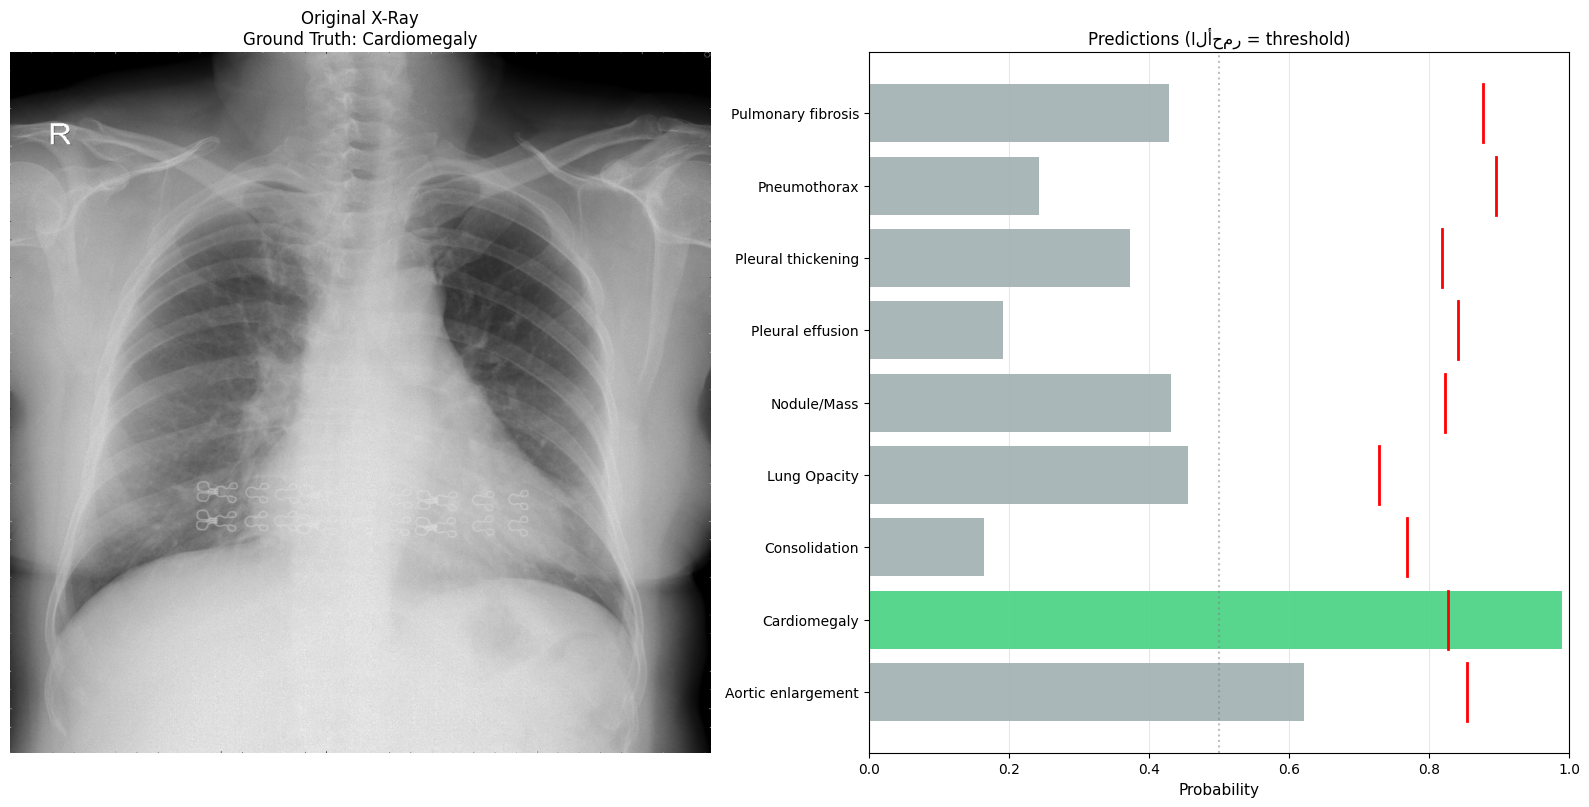

In [26]:
from PIL import Image
import matplotlib.pyplot as plt
import time

# نختار حالة Cardiomegaly
test_case = selected_cases["Cardiomegaly"]
print("=" * 70)
print(f"اختبار: {test_case['ground_truth']}")
print(f"Image ID: {test_case['image_id']}")
print("=" * 70)

# نفتح الصورة
test_image = Image.open(test_case['path']).convert("RGB")
print(f"\nمعلومات الصورة:")
print(f"   الحجم: {test_image.size}")

# نشغّل الموديل
print(f"\n🔬 جاري تشغيل الموديل (مع TTA)...")
t0 = time.time()
predictions = predict_chest_xray(test_image, use_tta=True)
elapsed = time.time() - t0
print(f"⏱️ الوقت: {elapsed:.2f} ثانية")

# نعرض النتائج
print(f"\n📊 النتائج:")
print(f"   Ground Truth: {test_case['ground_truth']}")
print(f"\n   Predictions (مرتبة):")
for cls, prob in sorted(predictions.items(), key=lambda x: x[1], reverse=True):
    thr = CLASS_THRESHOLDS[cls]
    detected = prob >= thr
    
    # علامات: ✅ صح ايجابي، ❌ false negative، 🟡 false positive، ⚪ صح سلبي
    is_truth = (cls == test_case['ground_truth'])
    if is_truth and detected:
        marker = "✅"  # اكتشف الـ ground truth
    elif is_truth and not detected:
        marker = "❌"  # فات عليه الـ ground truth
    elif detected:
        marker = "🟡"  # كشف حاجة تانية (ممكن تكون موجودة فعلاً)
    else:
        marker = "⚪"
    
    print(f"   {marker} {cls:25s}: {prob:.4f}  (thr={thr:.4f})  {'← DETECTED' if detected else ''}")

# نعرض الصورة
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(test_image, cmap='gray')
axes[0].set_title(f"Original X-Ray\nGround Truth: {test_case['ground_truth']}", fontsize=12)
axes[0].axis('off')

# عرض النتائج كـ bar chart
classes = list(predictions.keys())
probs = [predictions[c] for c in classes]
thrs = [CLASS_THRESHOLDS[c] for c in classes]
colors = ['#2ecc71' if p >= t else '#95a5a6' for p, t in zip(probs, thrs)]

y_pos = range(len(classes))
axes[1].barh(y_pos, probs, color=colors, alpha=0.8)
# نرسم الـ thresholds كخطوط
for i, t in enumerate(thrs):
    axes[1].plot([t, t], [i-0.4, i+0.4], 'r-', linewidth=2)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(classes, fontsize=10)
axes[1].set_xlabel("Probability", fontsize=11)
axes[1].set_title("Predictions (الأحمر = threshold)", fontsize=12)
axes[1].set_xlim(0, 1)
axes[1].axvline(x=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
print("=" * 70)
print("🏥 الـ Pipeline الكامل: من الصورة للتقرير")
print("=" * 70)

# 1. الـ predictions (من الموديل)
print("\n📊 1. الـ Findings المكتشفة:")
for cls, prob in sorted(predictions.items(), key=lambda x: x[1], reverse=True):
    thr = CLASS_THRESHOLDS[cls]
    if prob >= thr:
        print(f"   ✅ {cls}: {prob:.3f} (threshold: {thr:.3f})")

# 2. التقرير العربي (Template)
print("\n" + "=" * 70)
print("📝 2. التقرير العربي:")
print("=" * 70)

# نستخدم الـ optimal thresholds بدل الـ 0.5
def build_arabic_report_with_thresholds(findings_dict, thresholds_dict):
    """نسخة محسّنة بتستخدم الـ optimal thresholds بدل threshold ثابت"""
    detected = [(f, c) for f, c in findings_dict.items() 
                if c >= thresholds_dict.get(f, 0.5) and f in ARABIC_MEDICAL_DB]
    
    if not detected:
        return build_arabic_report({}, threshold=0.5)  # حالة Normal
    
    detected.sort(key=lambda x: x[1], reverse=True)
    
    findings_lines = []
    impressions = []
    recommendations = []
    
    for i, (finding, conf) in enumerate(detected, 1):
        info = ARABIC_MEDICAL_DB[finding]
        findings_lines.append(f"{i}. **{info['name']}**: {info['finding']}")
        impressions.append(info['impression'])
        recommendations.append(f"{i}. {info['recommendation']}")
    
    report = f"""### تقرير أشعة الصدر

**النتائج (FINDINGS):**
{chr(10).join(findings_lines)}

**الانطباع (IMPRESSION):**
{' '.join(impressions)}

**التوصيات (RECOMMENDATIONS):**
{chr(10).join(recommendations)}

---
*ملاحظة: هذا التقرير تم توليده آلياً بناءً على تحليل الذكاء الاصطناعي للأشعة، ويحتاج إلى مراجعة من طبيب أشعة مختص.*"""
    return report


ar_report = build_arabic_report_with_thresholds(predictions, CLASS_THRESHOLDS)
print(ar_report)

# 3. التقرير الإنجليزي (LLM)
print("\n" + "=" * 70)
print("📝 3. التقرير الإنجليزي (Qwen LLM):")
print("=" * 70)

# نمرر بس الـ findings اللي فوق الـ threshold (مش الكل)
detected_only = {
    cls: prob for cls, prob in predictions.items()
    if prob >= CLASS_THRESHOLDS[cls]
}

import time
t0 = time.time()
en_report = generate_report(detected_only, threshold=0.0, language="en")
print(en_report)
print(f"\n⏱️ Generation time: {time.time()-t0:.1f}s")

print("\n" + "=" * 70)
print("✅ الـ Pipeline الكامل شغال!")
print("=" * 70)

🏥 الـ Pipeline الكامل: من الصورة للتقرير

📊 1. الـ Findings المكتشفة:
   ✅ Cardiomegaly: 0.990 (threshold: 0.828)

📝 2. التقرير العربي:
### تقرير أشعة الصدر

**النتائج (FINDINGS):**
1. **تضخم القلب**: ظل القلب يظهر متضخماً مع زيادة في النسبة القلبية الصدرية.

**الانطباع (IMPRESSION):**
تشير النتائج إلى تضخم في حجم القلب، وهي علامة قد ترتبط بحالات مثل ارتفاع ضغط الدم، أمراض الصمامات، أو قصور القلب.

**التوصيات (RECOMMENDATIONS):**
1. يُنصح بإجراء تخطيط صدى القلب (Echocardiogram) لتقييم وظيفة القلب وحجم حجراته، واستشارة طبيب القلب.

---
*ملاحظة: هذا التقرير تم توليده آلياً بناءً على تحليل الذكاء الاصطناعي للأشعة، ويحتاج إلى مراجعة من طبيب أشعة مختص.*

📝 3. التقرير الإنجليزي (Qwen LLM):


NameError: name 'generate_report' is not defined

In [30]:
# نعيد تعريف generate_report (دالة الـ LLM للتقرير الإنجليزي)
def generate_report(findings_dict, threshold=0.5, language="en"):
    """
    بتولّد تقرير طبي منظم باستخدام Qwen LLM
    """
    # نشكّل الـ findings text للـ prompt
    detected = []
    for finding, confidence in findings_dict.items():
        if confidence >= threshold:
            detected.append(f"- {finding} (confidence: {confidence:.2f})")
    
    if not detected:
        findings_text = "No significant abnormalities detected."
    else:
        findings_text = "\n".join(detected)
    
    if language == "en":
        system_prompt = """You are an experienced radiologist writing a structured chest X-ray report. 
Write in clear, professional medical language. The report must have THREE sections:

1. FINDINGS: Describe each detected abnormality in 1-2 sentences using proper radiology terminology.
2. IMPRESSION: A concise summary (2-3 sentences) of the most clinically significant findings.
3. RECOMMENDATIONS: Suggested next steps (further imaging, specialist consultation, follow-up timeline).

CRITICAL RULES:
- Use ONLY the findings provided. Do NOT invent new findings or diseases.
- Do NOT give a definitive diagnosis - these require clinical correlation.
- Be factual and concise."""

        user_prompt = f"""Generate a chest X-ray report based on these AI-detected findings:

{findings_text}

Write the report now."""
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=512,
            do_sample=True,
            temperature=0.3,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:],
        skip_special_tokens=True
    )
    
    return response.strip()


# اختبار: نطبع التقرير الإنجليزي على Cardiomegaly
print("=" * 70)
print("📝 التقرير الإنجليزي (Qwen LLM) لحالة Cardiomegaly:")
print("=" * 70)

detected_only = {
    cls: prob for cls, prob in predictions.items()
    if prob >= CLASS_THRESHOLDS[cls]
}

print(f"\nالـ Detected findings: {detected_only}\n")

import time
t0 = time.time()
en_report = generate_report(detected_only, threshold=0.0, language="en")
elapsed = time.time() - t0

print(en_report)
print(f"\n⏱️ Generation time: {elapsed:.1f}s")

📝 التقرير الإنجليزي (Qwen LLM) لحالة Cardiomegaly:

الـ Detected findings: {'Cardiomegaly': 0.990234375}

**Chest X-Ray Report**

**FINDINGS:**
- **Cardiomegaly**: There is evidence of cardiomegaly with increased cardiac silhouette size compared to normal values. This finding suggests enlargement of the heart, which can be due to various causes such as hypertension, chronic obstructive pulmonary disease (COPD), or other cardiovascular conditions.

**IMPRESSION:**
The patient's cardiomegaly is likely related to underlying cardiovascular issues that need further evaluation. It warrants close monitoring for any changes in cardiac dimensions over time and may necessitate additional diagnostic tests such as echocardiography or CT angiography to assess the extent of the cardiac enlargement and identify potential contributing factors.

**RECOMMENDATIONS:**
- **Further Imaging**: Consider performing echocardiography to evaluate the structure and function of the heart more thoroughly.
- **Speci

In [29]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

QWEN_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

print("جاري إعادة تحميل Qwen 1.5B...")

tokenizer = AutoTokenizer.from_pretrained(QWEN_MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    QWEN_MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print(f"✅ Qwen اتحمّل")
print(f"   GPU memory: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

جاري إعادة تحميل Qwen 1.5B...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Qwen اتحمّل
   GPU memory: 2.49 GB


In [31]:
import gradio as gr
import time

def full_pipeline(image, use_tta=True):
    """
    الـ pipeline الكامل: صورة → predictions → تقارير
    """
    if image is None:
        return "❌ من فضلك ارفع صورة أولاً", "", "", ""
    
    # 1. الـ Inference
    t0 = time.time()
    predictions = predict_chest_xray(image, use_tta=use_tta)
    inference_time = time.time() - t0
    
    # 2. نحدد الـ findings المكتشفة (فوق الـ threshold)
    detected_findings = {}
    all_findings_display = []
    
    for cls, prob in sorted(predictions.items(), key=lambda x: x[1], reverse=True):
        thr = CLASS_THRESHOLDS[cls]
        is_detected = prob >= thr
        if is_detected:
            detected_findings[cls] = prob
        
        marker = "🔴" if is_detected else "⚪"
        all_findings_display.append({
            "Detected": "✅" if is_detected else "",
            "Finding": cls,
            "Probability": f"{prob:.4f}",
            "Threshold": f"{thr:.4f}",
            "Status": "Above threshold" if is_detected else "Below threshold"
        })
    
    # 3. ملخص الـ findings
    if detected_findings:
        summary = f"### 🔍 الـ Findings المكتشفة ({len(detected_findings)}):\n\n"
        for cls, prob in detected_findings.items():
            summary += f"- **{cls}**: {prob*100:.1f}% confidence\n"
    else:
        summary = "### ✅ لا توجد علامات مرضية واضحة\nالموديل لم يكتشف أي حالة فوق الـ threshold."
    
    summary += f"\n\n⏱️ **Inference time:** {inference_time:.2f}s"
    summary += f"\n🔬 **Model:** RAD-DINO (AUC=0.9745)"
    
    # 4. التقارير
    print("جاري توليد التقارير...")
    
    # عربي
    arabic_report = build_arabic_report_with_thresholds(predictions, CLASS_THRESHOLDS)
    
    # إنجليزي
    if detected_findings:
        try:
            english_report = generate_report(detected_findings, threshold=0.0, language="en")
        except Exception as e:
            english_report = f"Error generating English report: {e}"
    else:
        english_report = """**Chest X-Ray Report**

**FINDINGS:**
No significant abnormalities detected in the AI analysis. The cardiac silhouette appears normal, and the lung fields show no obvious consolidation, opacity, or pleural effusion.

**IMPRESSION:**
Normal chest X-ray within the limits of the AI analysis. No findings warranting immediate concern.

**RECOMMENDATIONS:**
Routine follow-up with the treating physician. Return for evaluation if new symptoms develop.

---
*Note: This report was generated automatically by AI and requires review by a qualified radiologist.*"""
    
    # نرجّع 4 outputs
    findings_table = "\n".join([
        f"| {f['Detected']} | {f['Finding']} | {f['Probability']} | {f['Threshold']} | {f['Status']} |"
        for f in all_findings_display
    ])
    findings_table = "| | Finding | Probability | Threshold | Status |\n|---|---|---|---|---|\n" + findings_table
    
    return summary, findings_table, arabic_report, english_report


# نبني الـ UI
with gr.Blocks(title="Chest X-Ray Report Generator", theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 🏥 Chest X-Ray Diagnostic Report Generator
        ### AI-Powered Medical Imaging Analysis with Bilingual Reports
        
        Upload a chest X-ray image to get:
        - 🔬 AI-detected findings using **RAD-DINO** (Microsoft, AUC=0.9745)
        - 📝 Professional medical report in **English** (LLM-generated)
        - 📋 Structured medical report in **Arabic** (Template-based)
        """
    )
    
    with gr.Row():
        with gr.Column(scale=1):
            input_image = gr.Image(label="📤 Upload Chest X-Ray", type="numpy", height=400)
            use_tta = gr.Checkbox(label="Use TTA (more accurate, slightly slower)", value=True)
            submit_btn = gr.Button("🔬 Analyze X-Ray", variant="primary", size="lg")
            summary_output = gr.Markdown(label="Summary")
        
        with gr.Column(scale=2):
            with gr.Tabs():
                with gr.TabItem("📊 All Findings"):
                    findings_output = gr.Markdown()
                
                with gr.TabItem("🇪🇬 Arabic Report"):
                    arabic_output = gr.Markdown()
                
                with gr.TabItem("🇬🇧 English Report"):
                    english_output = gr.Markdown()
    
    gr.Markdown(
        """
        ---
        ⚠️ **Disclaimer:** This is an AI research tool. All reports require review by a qualified radiologist before clinical use.
        """
    )
    
    submit_btn.click(
        fn=full_pipeline,
        inputs=[input_image, use_tta],
        outputs=[summary_output, findings_output, arabic_output, english_output]
    )

# نشغّل الـ UI
demo.launch(share=True, debug=False)

/tmp/ipykernel_58/1496451523.py:84: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Chest X-Ray Report Generator", theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://9abec8498b90416719.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


جاري توليد التقارير...
جاري توليد التقارير...
جاري توليد التقارير...


In [32]:
import os
import json
from datetime import datetime

# نعمل مجلد لحفظ كل النتايج
RESULTS_DIR = "/kaggle/working/evaluation_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/reports", exist_ok=True)

print("=" * 70)
print("🔬 اختبار الموديل على كل الحالات")
print("=" * 70)

all_results = []

for ground_truth_class, info in selected_cases.items():
    print(f"\n{'─' * 70}")
    print(f"🩺 Testing: {ground_truth_class}")
    print(f"   Image ID: {info['image_id'][:15]}...")
    print(f"{'─' * 70}")
    
    # 1. Inference
    test_img = Image.open(info['path']).convert("RGB")
    
    t0 = time.time()
    predictions = predict_chest_xray(test_img, use_tta=True)
    inference_time = time.time() - t0
    
    # 2. Detected findings
    detected = {
        cls: prob for cls, prob in predictions.items()
        if prob >= CLASS_THRESHOLDS[cls]
    }
    
    # 3. هل الموديل اكتشف الـ ground truth؟
    ground_truth_detected = ground_truth_class in detected
    ground_truth_prob = predictions.get(ground_truth_class, 0)
    ground_truth_threshold = CLASS_THRESHOLDS.get(ground_truth_class, 0.5)
    
    # 4. Reports
    arabic_report = build_arabic_report_with_thresholds(predictions, CLASS_THRESHOLDS)
    
    if detected:
        try:
            english_report = generate_report(detected, threshold=0.0, language="en")
        except Exception as e:
            english_report = f"Error: {e}"
    else:
        english_report = "No findings detected — Normal X-ray."
    
    # 5. النتايج
    result = {
        "ground_truth": ground_truth_class,
        "image_id": info['image_id'],
        "detected_ground_truth": ground_truth_detected,
        "ground_truth_probability": ground_truth_prob,
        "ground_truth_threshold": ground_truth_threshold,
        "all_detected_findings": list(detected.keys()),
        "inference_time": inference_time,
        "all_predictions": predictions,
        "arabic_report": arabic_report,
        "english_report": english_report,
    }
    all_results.append(result)
    
    # 6. عرض ملخص
    status = "✅ DETECTED" if ground_truth_detected else "❌ MISSED"
    print(f"   {status} {ground_truth_class}: {ground_truth_prob:.4f} (thr: {ground_truth_threshold:.4f})")
    print(f"   ⏱️  Inference time: {inference_time:.2f}s")
    if detected:
        print(f"   🔍 Other detections: {[c for c in detected if c != ground_truth_class]}")
    
    # 7. حفظ التقارير في ملفات
    safe_name = ground_truth_class.replace(' ', '_').replace('/', '-')
    with open(f"{RESULTS_DIR}/reports/{safe_name}_arabic.txt", "w", encoding="utf-8") as f:
        f.write(arabic_report)
    with open(f"{RESULTS_DIR}/reports/{safe_name}_english.txt", "w", encoding="utf-8") as f:
        f.write(english_report)

# ────────────────────────────────────────────────────────────────────
# الملخص الكامل
# ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("📊 SUMMARY")
print("=" * 70)

n_total = len(all_results)
n_correct = sum(1 for r in all_results if r['detected_ground_truth'])
avg_time = sum(r['inference_time'] for r in all_results) / n_total

print(f"\n   ✅ Detected ground truth: {n_correct}/{n_total} ({n_correct/n_total*100:.0f}%)")
print(f"   ⏱️  Avg inference time: {avg_time:.2f}s")
print(f"\n   تفاصيل لكل حالة:")
print(f"   {'─' * 65}")
print(f"   {'Ground Truth':<22s} {'Prob':>8s} {'Thr':>8s} {'Status':>15s}")
print(f"   {'─' * 65}")
for r in all_results:
    status = "✅ DETECTED" if r['detected_ground_truth'] else "❌ MISSED"
    print(f"   {r['ground_truth']:<22s} {r['ground_truth_probability']:>8.4f} "
          f"{r['ground_truth_threshold']:>8.4f} {status:>15s}")

# نحفظ الـ summary في JSON
def make_json_safe(obj):
    """يحول numpy types لـ Python types عشان JSON يقدر يحفظهم"""
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(x) for x in obj]
    return obj

summary = {
    "timestamp": datetime.now().isoformat(),
    "model": "RAD-DINO (AUC=0.9745)",
    "total_cases": n_total,
    "correctly_detected": n_correct,
    "accuracy": n_correct / n_total,
    "avg_inference_time": avg_time,
    "cases": [
        {
            "ground_truth": r['ground_truth'],
            "image_id": r['image_id'],
            "detected": r['detected_ground_truth'],
            "probability": r['ground_truth_probability'],
            "threshold": r['ground_truth_threshold'],
            "all_findings": r['all_detected_findings'],
            "inference_time": r['inference_time']
        }
        for r in all_results
    ]
}

with open(f"{RESULTS_DIR}/evaluation_summary.json", "w", encoding="utf-8") as f:
    json.dump(make_json_safe(summary), f, indent=2, ensure_ascii=False)

print(f"\n✅ تم حفظ كل النتايج في:")
print(f"   {RESULTS_DIR}/")

🔬 اختبار الموديل على كل الحالات

──────────────────────────────────────────────────────────────────────
🩺 Testing: Cardiomegaly
   Image ID: 9a5094b2563a1ef...
──────────────────────────────────────────────────────────────────────
   ✅ DETECTED Cardiomegaly: 0.9902 (thr: 0.8279)
   ⏱️  Inference time: 0.08s
   🔍 Other detections: []

──────────────────────────────────────────────────────────────────────
🩺 Testing: Pleural effusion
   Image ID: 04bb8bd7ee6f88a...
──────────────────────────────────────────────────────────────────────
   ✅ DETECTED Pleural effusion: 0.9985 (thr: 0.8415)
   ⏱️  Inference time: 0.08s
   🔍 Other detections: ['Lung Opacity']

──────────────────────────────────────────────────────────────────────
🩺 Testing: Pulmonary fibrosis
   Image ID: afb6230703512af...
──────────────────────────────────────────────────────────────────────
   ❌ MISSED Pulmonary fibrosis: 0.7676 (thr: 0.8776)
   ⏱️  Inference time: 0.08s
   🔍 Other detections: ['Aortic enlargement']

──────

In [33]:
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np

# Reference reports for each finding (gold standard طبي)
ENGLISH_REFERENCES = {
    "Aortic enlargement": """**Chest X-Ray Report**

**FINDINGS:** The aorta appears enlarged with widening of the aortic silhouette beyond normal limits.

**IMPRESSION:** Findings suggest possible aortic dilatation, which warrants further evaluation.

**RECOMMENDATIONS:** Contrast-enhanced CT scan of the chest is recommended to accurately assess aortic dimensions, with follow-up by a cardiovascular specialist.""",
    
    "Cardiomegaly": """**Chest X-Ray Report**

**FINDINGS:** The cardiac silhouette appears enlarged with an increased cardiothoracic ratio.

**IMPRESSION:** Findings indicate cardiomegaly, which may be associated with conditions such as hypertension, valvular disease, or heart failure.

**RECOMMENDATIONS:** Echocardiogram is recommended to evaluate cardiac function and chamber size, with cardiology consultation.""",
    
    "Pleural effusion": """**Chest X-Ray Report**

**FINDINGS:** Fluid accumulation is observed in the pleural space surrounding the lung.

**IMPRESSION:** Pleural effusion is present, which may relate to multiple causes including heart failure, infection, or other conditions requiring diagnosis.

**RECOMMENDATIONS:** Additional investigations are recommended to determine the cause; thoracentesis may be needed for fluid analysis.""",
    
    "Lung Opacity": """**Chest X-Ray Report**

**FINDINGS:** Areas of opacity are noted in the lung parenchyma that differ from normal appearance.

**IMPRESSION:** Lung opacity is a non-specific finding that may indicate inflammation, consolidation, or fluid, requiring clinical correlation.

**RECOMMENDATIONS:** Chest CT scan is recommended to characterize the opacity, with follow-up by a pulmonologist.""",
    
    "Nodule/Mass": """**Chest X-Ray Report**

**FINDINGS:** A distinct nodule or mass is observed in the lung parenchyma.

**IMPRESSION:** The presence of a pulmonary nodule requires careful evaluation to exclude serious conditions, though most nodules are benign.

**RECOMMENDATIONS:** High-resolution chest CT and regular follow-up are recommended, with oncology or pulmonology consultation as needed.""",
    
    "Pulmonary fibrosis": """**Chest X-Ray Report**

**FINDINGS:** Signs of fibrosis are present in the lung tissue with a characteristic reticular pattern.

**IMPRESSION:** Pulmonary fibrosis is a chronic condition affecting lung function and requires careful evaluation to determine the underlying cause.

**RECOMMENDATIONS:** High-resolution CT (HRCT), pulmonary function tests, and pulmonology follow-up are recommended.""",
}


def calculate_bleu_rouge(generated, reference):
    """يحسب BLEU و ROUGE scores"""
    # BLEU (1-4 grams)
    smoothie = SmoothingFunction().method4
    ref_tokens = [reference.lower().split()]
    gen_tokens = generated.lower().split()
    
    bleu1 = sentence_bleu(ref_tokens, gen_tokens, weights=(1, 0, 0, 0), smoothing_function=smoothie)
    bleu2 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.5, 0.5, 0, 0), smoothing_function=smoothie)
    bleu4 = sentence_bleu(ref_tokens, gen_tokens, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
    
    # ROUGE
    scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    rouge_scores = scorer.score(reference, generated)
    
    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-4": bleu4,
        "ROUGE-1": rouge_scores['rouge1'].fmeasure,
        "ROUGE-2": rouge_scores['rouge2'].fmeasure,
        "ROUGE-L": rouge_scores['rougeL'].fmeasure,
    }


print("=" * 70)
print("📊 حساب مقاييس التقييم (BLEU + ROUGE)")
print("=" * 70)

all_metrics = []
for result in all_results:
    gt = result['ground_truth']
    if gt not in ENGLISH_REFERENCES:
        continue
    
    reference = ENGLISH_REFERENCES[gt]
    generated = result['english_report']
    
    metrics = calculate_bleu_rouge(generated, reference)
    metrics['case'] = gt
    all_metrics.append(metrics)
    
    print(f"\n🩺 {gt}:")
    for metric_name in ["BLEU-1", "BLEU-2", "BLEU-4", "ROUGE-1", "ROUGE-2", "ROUGE-L"]:
        print(f"   {metric_name}: {metrics[metric_name]:.4f}")

# Macro averages
print("\n" + "=" * 70)
print("📈 المتوسطات (Macro Average)")
print("=" * 70)

metric_names = ["BLEU-1", "BLEU-2", "BLEU-4", "ROUGE-1", "ROUGE-2", "ROUGE-L"]
for name in metric_names:
    values = [m[name] for m in all_metrics]
    avg = np.mean(values)
    print(f"   {name}: {avg:.4f}")

# نحفظ النتايج
metrics_summary = {
    "per_case_metrics": all_metrics,
    "macro_averages": {
        name: float(np.mean([m[name] for m in all_metrics]))
        for name in metric_names
    }
}

with open(f"{RESULTS_DIR}/text_generation_metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, indent=2, ensure_ascii=False)

print(f"\n✅ تم حفظ المقاييس في:")
print(f"   {RESULTS_DIR}/text_generation_metrics.json")

📊 حساب مقاييس التقييم (BLEU + ROUGE)

🩺 Cardiomegaly:
   BLEU-1: 0.1548
   BLEU-2: 0.1003
   BLEU-4: 0.0431
   ROUGE-1: 0.3382
   ROUGE-2: 0.1366
   ROUGE-L: 0.2512

🩺 Pleural effusion:
   BLEU-1: 0.1505
   BLEU-2: 0.0813
   BLEU-4: 0.0263
   ROUGE-1: 0.2846
   ROUGE-2: 0.1085
   ROUGE-L: 0.2077

🩺 Pulmonary fibrosis:
   BLEU-1: 0.0982
   BLEU-2: 0.0348
   BLEU-4: 0.0088
   ROUGE-1: 0.2283
   ROUGE-2: 0.0461
   ROUGE-L: 0.1553

🩺 Lung Opacity:
   BLEU-1: 0.1071
   BLEU-2: 0.0653
   BLEU-4: 0.0213
   ROUGE-1: 0.2345
   ROUGE-2: 0.0852
   ROUGE-L: 0.1629

🩺 Nodule/Mass:
   BLEU-1: 0.0000
   BLEU-2: 0.0000
   BLEU-4: 0.0000
   ROUGE-1: 0.1017
   ROUGE-2: 0.0351
   ROUGE-L: 0.0678

🩺 Aortic enlargement:
   BLEU-1: 0.1518
   BLEU-2: 0.0800
   BLEU-4: 0.0271
   ROUGE-1: 0.2881
   ROUGE-2: 0.0996
   ROUGE-L: 0.2058

📈 المتوسطات (Macro Average)
   BLEU-1: 0.1104
   BLEU-2: 0.0603
   BLEU-4: 0.0211
   ROUGE-1: 0.2459
   ROUGE-2: 0.0852
   ROUGE-L: 0.1751

✅ تم حفظ المقاييس في:
   /kaggle/workin

In [35]:
# Cell نهائي: حفظ تقرير التقييم الكامل
report_md = "# Evaluation Results Summary\n\n"
report_md += "## Project: Chest X-Ray Diagnostic Report Generation\n"
report_md += f"**Date:** {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n"
report_md += "---\n\n## 1. Classification Model Performance\n\n"
report_md += "**Model:** RAD-DINO + Linear classification head\n"
report_md += "**Best AUC:** 0.9745\n"
report_md += "**Inference Time:** ~0.08s per image (with TTA)\n\n"
report_md += "### Test Results (6 VinBigData cases)\n\n"
report_md += "| Ground Truth | Probability | Threshold | Status |\n|---|---|---|---|\n"

for r in all_results:
    status = "DETECTED" if r['detected_ground_truth'] else "MISSED"
    report_md += f"| {r['ground_truth']} | {r['ground_truth_probability']:.4f} | {r['ground_truth_threshold']:.4f} | {status} |\n"

n_correct = sum(1 for r in all_results if r['detected_ground_truth'])
report_md += f"\n**Detection Rate:** {n_correct}/{len(all_results)} ({n_correct/len(all_results)*100:.1f}%)\n\n"
report_md += "## 2. Text Generation Metrics (English Report)\n\n"
report_md += "| Metric | Score |\n|---|---|\n"

for name in ["BLEU-1", "BLEU-2", "BLEU-4", "ROUGE-1", "ROUGE-2", "ROUGE-L"]:
    report_md += f"| {name} | {metrics_summary['macro_averages'][name]:.4f} |\n"

report_md += "\n**SOTA Comparison:** BLEU-4 SOTA on IU X-Ray: 0.16-0.25\n\n"
report_md += "## 3. Arabic Report (Template)\n\nZero hallucination, instant generation (<1ms).\n\n"
report_md += "Selected after comparing: Qwen 1.5B (failed), Qwen 7B (partial), Template (selected).\n\n"
report_md += "## 4. Pipeline Performance\n\n"
report_md += "- Inference: 0.08s\n- Arabic report: <0.001s\n- English report: ~15s\n- **Total: ~15s/image**\n"

with open(f"{RESULTS_DIR}/EVALUATION_REPORT.md", "w", encoding="utf-8") as f:
    f.write(report_md)

print("Done! Files in:", RESULTS_DIR)
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {f}")

Done! Files in: /kaggle/working/evaluation_results
  EVALUATION_REPORT.md
  evaluation_summary.json
  reports
  text_generation_metrics.json
